# **Case study: RNA-Seq analysis pipeline on public dataset**   

### *Notebook Overview* 
This notebook presents an example of a complete RNA-Seq analysis pipeline.
The project is divided into 3 modules:
- Module A: fastq file retrieval, preprocessing, and mapping to the reference transcriptome. Implemented as a bash pipeline.
- Module B: differential expression analysis using DESeq2. Implemented in R.
- Module C: Functional enrichment analysis through literature study and ClusterProfiler (in R).

Comments on intermediate findings, biological insights, and figures are included throughout the project, alternating with code sections.  
<br>

### *Dataset Description*
This is a bulk RNA-sequencing dataset of in-vitro Th2 cells, subjected to L-phenylalanine treatment to assess its effect on gene expression. Cells were obtained from 5 donors, and incubated for 24h with either Phenylalanine or Vehicle (Ctrl) with simultaneous activation with anti-CD2, anti-CD3 and anti-CD28 antibody beads.  
<br>
The **experimental design** therefore consists of:
- 10 samples (S1-S10).
- From 5 different donors (D1-D5).
- On 2 conditions: L-Phenylalanine treatment and Veh treatment (Ctrl).
- Paired setup (Phe vs Ctrl on the same donor): design = ~ donor + condition.
<br>

Sequencing was performed with the Illumina NovaSeq X Plus platform.  
Raw data were obtained from the GEO database, under accession number: **GSE291310**

# *Module A: Preprocessing and mapping*

## **Section 0:** Setting-up conda environment ##
Preliminary step: preparing the conda work environment.

In [ ]:
conda create -n bioinf

conda activate bioinf

conda install -c bioconda -c conda-forge \
  sra-tools \
  fastqc \
  multiqc \
  fastp \
  kallisto 

  **Tool :       Version**   
  sra-tools :  3.2.1  
  fastqc :     0.12.1  
  multiqc :    1.33  
  fastp :      1.1.0  
  kallisto :   0.51.1

## **Section 1:** Importing the data

Retrieving the data from the NCBI SRA database.

Creating a file with the codes of the files to download ("accession_list"). Then downloading them in a loop and compressing them:

In [ ]:
mkdir -p ~/PROJECTS/rna_seq
cd ~/PROJECTS/rna_seq

#Creating a file containing the SRA codes: nano accession_list.txt
cat accession_list.txt

SRR32600245
SRR32600247
SRR32600249
SRR32600251
SRR32600253
SRR32600255
SRR32600257
SRR32600259
SRR32600261
SRR32600263


In [ ]:
while read id; do
    echo "Downloading sample: $id"
    
    # 1. Downloading and splitting R1 and R2 (Paired design)
    fasterq-dump "$id" --split-files
    
    # 2. Compressing
    gzip "${id}_1.fastq" "${id}_2.fastq"
    
    echo "Sample $id downloaded and compressed."
    echo "------------------------------------"
done < accession_list.txt

spots read      : 16,208,668
reads read      : 32,417,336
reads written   : 32,417,336


Sample SRR32600245 downloaded and compressed.
------------------------------------


spots read      : 15,865,994
reads read      : 31,731,988
reads written   : 31,731,988


Sample SRR32600247 downloaded and compressed.
------------------------------------


spots read      : 16,713,310
reads read      : 33,426,620
reads written   : 33,426,620


...

Sample SRR32600259 downloaded and compressed.
------------------------------------


spots read      : 13,770,341
reads read      : 27,540,682
reads written   : 27,540,682


Sample SRR32600261 downloaded and compressed.
------------------------------------


spots read      : 12,030,057
reads read      : 24,060,114
reads written   : 24,060,114


Sample SRR32600263 downloaded and compressed.
------------------------------------


Quickly checking files were correctly downloaded and have the correct format:

In [ ]:
zcat "SRR32600257_2.fastq.gz" | head -n 12

@SRR32600257.1 LH00289:182:22VFM2LT3:7:1101:12659:1048 length=151
NTAGCCCTCGTAGTAACAGCCATTCTCATCCAAACCCCCTGAAGCTTCACCGGCGCAGTCATTCTCATAATCGCCCACGGGCTTACATCCTCATTACTATTCTGCCTAGCAAACTCAAACTACGAACGCACTCACAGTCGCATCATAATCC
+SRR32600257.1 LH00289:182:22VFM2LT3:7:1101:12659:1048 length=151
#IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII
@SRR32600257.2 LH00289:182:22VFM2LT3:7:1101:17597:1048 length=151
NNTCAACTTTAACACCGACGAGCAGGCACTGGAAGACCACTTCAGCAGTTTCGGACCTATCTCTGAGGTGGACTGTCTCTTATACACATCTGACGCTGCCGACGATGGTATACCAGTGTAGATCTCGGTGGTCGCCGTATCATTAAAAAGG
+SRR32600257.2 LH00289:182:22VFM2LT3:7:1101:17597:1048 length=151
##IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII-IIIIIIIIII99III
@SRR32600257.3 LH00289:182:22VFM2LT3:7:1101:19409:1048 length=151
NNAGAATATCTCGGGAATGGACTCAGAAGTATGCCATGTGATGCTACCTTAAAGTCAGAATA

## **Section 2**: Quality Control #1

Checking the quality of the reads with fastqc:

In [ ]:
mkdir -p ~/PROJECTS/rna_seq/fastqc_results
cd ~/PROJECTS/rna_seq

# fastqc on all files
fastqc -t 2 -o fastqc_results/ *.fastq.gz

application/gzip
application/gzip


application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip


Started analysis of SRR32600245_1.fastq.gz
Started analysis of SRR32600245_2.fastq.gz
Approx 5% complete for SRR32600245_1.fastq.gz
Approx 5% complete for SRR32600245_2.fastq.gz
Approx 10% complete for SRR32600245_1.fastq.gz
Approx 10% complete for SRR32600245_2.fastq.gz
Approx 15% complete for SRR32600245_1.fastq.gz
Approx 15% complete for SRR32600245_2.fastq.gz
Approx 20% complete for SRR32600245_1.fastq.gz
Approx 20% complete for SRR32600245_2.fastq.gz
Approx 25% complete for SRR32600245_1.fastq.gz
Approx 25% complete for SRR32600245_2.fastq.gz
Approx 30% complete for SRR32600245_1.fastq.gz
Approx 30% complete for SRR32600245_2.fastq.gz
Approx 35% complete for SRR32600245_1.fastq.gz
Approx 35% complete for SRR32600245_2.fastq.gz
Approx 40% complete for SRR32600245_1.fastq.gz
Approx 40% complete for SRR32600245_2.fastq.gz
Approx 45% complete for SRR32600245_1.fastq.gz
Approx 45% complete for SRR32600245_2.fastq.gz
Approx 50% complete for SRR32600245_1.fastq.gz
Approx 50% complete for

Analysis complete for SRR32600245_2.fastq.gz
Analysis complete for SRR32600245_1.fastq.gz


Started analysis of SRR32600247_1.fastq.gz
Started analysis of SRR32600247_2.fastq.gz
Approx 5% complete for SRR32600247_1.fastq.gz
Approx 5% complete for SRR32600247_2.fastq.gz
Approx 10% complete for SRR32600247_1.fastq.gz
Approx 10% complete for SRR32600247_2.fastq.gz
Approx 15% complete for SRR32600247_1.fastq.gz
Approx 15% complete for SRR32600247_2.fastq.gz
Approx 20% complete for SRR32600247_1.fastq.gz
Approx 20% complete for SRR32600247_2.fastq.gz
Approx 25% complete for SRR32600247_1.fastq.gz
Approx 25% complete for SRR32600247_2.fastq.gz
Approx 30% complete for SRR32600247_1.fastq.gz
Approx 30% complete for SRR32600247_2.fastq.gz
Approx 35% complete for SRR32600247_1.fastq.gz
Approx 35% complete for SRR32600247_2.fastq.gz
Approx 40% complete for SRR32600247_1.fastq.gz
Approx 40% complete for SRR32600247_2.fastq.gz
Approx 45% complete for SRR32600247_1.fastq.gz
Approx 45% complete for SRR32600247_2.fastq.gz
Approx 50% complete for SRR32600247_1.fastq.gz
Approx 50% complete for

...

Analysis complete for SRR32600259_2.fastq.gz


Started analysis of SRR32600261_2.fastq.gz
Approx 5% complete for SRR32600261_1.fastq.gz
Approx 5% complete for SRR32600261_2.fastq.gz
Approx 10% complete for SRR32600261_1.fastq.gz
Approx 10% complete for SRR32600261_2.fastq.gz
Approx 15% complete for SRR32600261_1.fastq.gz
Approx 15% complete for SRR32600261_2.fastq.gz
Approx 20% complete for SRR32600261_1.fastq.gz
Approx 20% complete for SRR32600261_2.fastq.gz
Approx 25% complete for SRR32600261_1.fastq.gz
Approx 25% complete for SRR32600261_2.fastq.gz
Approx 30% complete for SRR32600261_1.fastq.gz
Approx 30% complete for SRR32600261_2.fastq.gz
Approx 35% complete for SRR32600261_1.fastq.gz
Approx 35% complete for SRR32600261_2.fastq.gz
Approx 40% complete for SRR32600261_1.fastq.gz
Approx 40% complete for SRR32600261_2.fastq.gz
Approx 45% complete for SRR32600261_1.fastq.gz
Approx 45% complete for SRR32600261_2.fastq.gz
Approx 50% complete for SRR32600261_1.fastq.gz
Approx 50% complete for SRR32600261_2.fastq.gz
Approx 55% complete

Analysis complete for SRR32600261_1.fastq.gz
Analysis complete for SRR32600261_2.fastq.gz


Started analysis of SRR32600263_1.fastq.gz
Started analysis of SRR32600263_2.fastq.gz
Approx 5% complete for SRR32600263_1.fastq.gz
Approx 5% complete for SRR32600263_2.fastq.gz
Approx 10% complete for SRR32600263_1.fastq.gz
Approx 10% complete for SRR32600263_2.fastq.gz
Approx 15% complete for SRR32600263_1.fastq.gz
Approx 15% complete for SRR32600263_2.fastq.gz
Approx 20% complete for SRR32600263_1.fastq.gz
Approx 20% complete for SRR32600263_2.fastq.gz
Approx 25% complete for SRR32600263_1.fastq.gz
Approx 25% complete for SRR32600263_2.fastq.gz
Approx 30% complete for SRR32600263_1.fastq.gz
Approx 30% complete for SRR32600263_2.fastq.gz
Approx 35% complete for SRR32600263_1.fastq.gz
Approx 35% complete for SRR32600263_2.fastq.gz
Approx 40% complete for SRR32600263_1.fastq.gz
Approx 40% complete for SRR32600263_2.fastq.gz
Approx 45% complete for SRR32600263_1.fastq.gz
Approx 45% complete for SRR32600263_2.fastq.gz
Approx 50% complete for SRR32600263_1.fastq.gz
Approx 50% complete for

Analysis complete for SRR32600263_2.fastq.gz
Analysis complete for SRR32600263_1.fastq.gz


Merging in a single QC file: multiqc.

In [ ]:
multiqc ~/PROJECTS/rna_seq/fastqc_results/ -n full_qc_report.html -o fastqc_results/


/// ]8;id=281911;https://multiqc.info\MultiQC]8;;\ 🔍 v1.33

       file_search | Search path: /home/ubuntu/PROJECTS/rna_seq/fastqc_results
         searching | ━━━━━━━━━━━━━━━━━━━━1m╸━━ ━━━━━   0% 0/40   30% 12/40 fastqc_results/SRR32600249_1_fastqc.html 70% 28/40 fastqc_results/SRR32600259_2_fastqc.html━━━━━━━━━━━━━━━━━━━━ 100% 40/40  
            fastqc | Found 20 reports
     write_results | Data        : fastqc_results/full_qc_report_data
     write_results | Report      : fastqc_results/full_qc_report.html
           multiqc | MultiQC complete


Results: [MultiQC Report - Pre-trimming](https://pierpaolo-cantisani.github.io/RNA-Seq-analysis/fastqc_results/full_qc_report.html)  
<br>
The number of sequences was moderately consistent among the samples, ranging from 13M to 17.5M reads, with a steady GC content of 48-49% and similar duplicate levels, varying between 37.6% and 46.9%.
The samples consistently show good overall quality, passing quality checks for almost all relevant metrics.  
The only critical point is the adapter content, which is high (between 4% and 10%) across almost all samples.  
Adapter sequence trimming is therefore needed before proceeding with the mapping.

## **Section 3:** Trimming and Quality Control #2

Trimming adapter sequences and filtering for quality: fastp.

In [ ]:
cd ~/PROJECTS/rna_seq
mkdir -p ~/PROJECTS/rna_seq/trimmed

while read -r id; do
  echo "Trimming sample: $id"
  fastp \
    --thread 4 \
    --in1 "$HOME/PROJECTS/rna_seq/${id}_1.fastq.gz" \
    --in2 "$HOME/PROJECTS/rna_seq/${id}_2.fastq.gz" \
    --out1 "$HOME/PROJECTS/rna_seq/trimmed/${id}_1.trimmed.fastq.gz" \
    --out2 "$HOME/PROJECTS/rna_seq/trimmed/${id}_2.trimmed.fastq.gz"
done < accession_list.txt

Trimming sample: SRR32600245


Read1 before filtering:
total reads: 16208668
total bases: 2447508868
Q20 bases: 2393553835(97.7955%)
Q30 bases: 2297386554(93.8663%)
Q40 bases: 2297386554(93.8663%)

Read2 before filtering:
total reads: 16208668
total bases: 2447508868
Q20 bases: 2401613184(98.1248%)
Q30 bases: 2323581975(94.9366%)
Q40 bases: 2323581975(94.9366%)

Read1 after filtering:
total reads: 16049680
total bases: 2397118165
Q20 bases: 2351465160(98.0955%)
Q30 bases: 2263467449(94.4245%)
Q40 bases: 2263467449(94.4245%)

Read2 after filtering:
total reads: 16049680
total bases: 2397118165
Q20 bases: 2360965714(98.4918%)
Q30 bases: 2291443991(95.5916%)
Q40 bases: 2291443991(95.5916%)

Filtering result:
reads passed filter: 32099360
reads failed due to low quality: 315426
reads failed due to too many N: 2550
reads failed due to too short: 0
reads failed due to adapter dimer: 0
reads with adapter trimmed: 2404978
bases trimmed due to adapters: 52852482

Duplication rate: 12.4858%

Insert size peak (evaluated by pai

Trimming sample: SRR32600247


Read1 before filtering:
total reads: 15865994
total bases: 2395765094
Q20 bases: 2347520471(97.9863%)
Q30 bases: 2260854423(94.3688%)
Q40 bases: 2260854423(94.3688%)

Read2 before filtering:
total reads: 15865994
total bases: 2395765094
Q20 bases: 2346567206(97.9465%)
Q30 bases: 2267154227(94.6317%)
Q40 bases: 2267154227(94.6317%)

Read1 after filtering:
total reads: 15698078
total bases: 2344218430
Q20 bases: 2303999319(98.2843%)
Q30 bases: 2225583766(94.9393%)
Q40 bases: 2225583766(94.9393%)

Read2 after filtering:
total reads: 15698078
total bases: 2344218430
Q20 bases: 2305970270(98.3684%)
Q30 bases: 2235883340(95.3786%)
Q40 bases: 2235883340(95.3786%)

Filtering result:
reads passed filter: 31396156
reads failed due to low quality: 333520
reads failed due to too many N: 2312
reads failed due to too short: 0
reads failed due to adapter dimer: 0
reads with adapter trimmed: 2290172
bases trimmed due to adapters: 52477006

Duplication rate: 10.2667%

Insert size peak (evaluated by pai

Trimming sample: SRR32600249


...

Read1 before filtering:
total reads: 16152752
total bases: 2439065552
Q20 bases: 2386909896(97.8617%)
Q30 bases: 2295153642(94.0997%)
Q40 bases: 2295153642(94.0997%)

Read2 before filtering:
total reads: 16152752
total bases: 2439065552
Q20 bases: 2383548918(97.7239%)
Q30 bases: 2296608645(94.1594%)
Q40 bases: 2296608645(94.1594%)

Read1 after filtering:
total reads: 15959926
total bases: 2373770439
Q20 bases: 2331424832(98.2161%)
Q30 bases: 2249777750(94.7766%)
Q40 bases: 2249777750(94.7766%)

Read2 after filtering:
total reads: 15959926
total bases: 2373770439
Q20 bases: 2331013132(98.1988%)
Q30 bases: 2255176418(95.004%)
Q40 bases: 2255176418(95.004%)

Filtering result:
reads passed filter: 31919852
reads failed due to low quality: 383028
reads failed due to too many N: 2624
reads failed due to too short: 0
reads failed due to adapter dimer: 0
reads with adapter trimmed: 3077672
bases trimmed due to adapters: 72498838

Duplication rate: 9.0477%

Insert size peak (evaluated by paired

Trimming sample: SRR32600261


Read1 before filtering:
total reads: 13770341
total bases: 2079321491
Q20 bases: 2033264875(97.785%)
Q30 bases: 1953528188(93.9503%)
Q40 bases: 1953528188(93.9503%)

Read2 before filtering:
total reads: 13770341
total bases: 2079321491
Q20 bases: 2036995014(97.9644%)
Q30 bases: 1970599982(94.7713%)
Q40 bases: 1970599982(94.7713%)

Read1 after filtering:
total reads: 13621138
total bases: 2024660140
Q20 bases: 1987432284(98.1613%)
Q30 bases: 1916313346(94.6486%)
Q40 bases: 1916313346(94.6486%)

Read2 after filtering:
total reads: 13621138
total bases: 2024660140
Q20 bases: 1993464831(98.4592%)
Q30 bases: 1935899003(95.616%)
Q40 bases: 1935899003(95.616%)

Filtering result:
reads passed filter: 27242276
reads failed due to low quality: 296110
reads failed due to too many N: 2296
reads failed due to too short: 0
reads failed due to adapter dimer: 0
reads with adapter trimmed: 2716172
bases trimmed due to adapters: 64380330

Duplication rate: 11.4796%

Insert size peak (evaluated by paired

Trimming sample: SRR32600263


Read1 before filtering:
total reads: 12030057
total bases: 1816538607
Q20 bases: 1775988761(97.7677%)
Q30 bases: 1706437880(93.939%)
Q40 bases: 1706437880(93.939%)

Read2 before filtering:
total reads: 12030057
total bases: 1816538607
Q20 bases: 1782328637(98.1167%)
Q30 bases: 1728901698(95.1756%)
Q40 bases: 1728901698(95.1756%)

Read1 after filtering:
total reads: 11896506
total bases: 1751351036
Q20 bases: 1719521247(98.1826%)
Q30 bases: 1658729570(94.7114%)
Q40 bases: 1658729570(94.7114%)

Read2 after filtering:
total reads: 11896506
total bases: 1751351036
Q20 bases: 1725922149(98.548%)
Q30 bases: 1680549227(95.9573%)
Q40 bases: 1680549227(95.9573%)

Filtering result:
reads passed filter: 23793012
reads failed due to low quality: 265212
reads failed due to too many N: 1890
reads failed due to too short: 0
reads failed due to adapter dimer: 0
reads with adapter trimmed: 4194222
bases trimmed due to adapters: 90220714

Duplication rate: 10.6075%

Insert size peak (evaluated by paired

Repeating QC on the trimmed reads:

In [ ]:
mkdir -p ~/PROJECTS/rna_seq/trimmed/fastqc_results
cd ~/PROJECTS/rna_seq/trimmed

fastqc -t 2 -o fastqc_results *.fastq.gz

multiqc fastqc_results/ -n full_qc_report_trimmed.html -o fastqc_results/

application/gzip
application/gzip


Started analysis of SRR32600245_1.trimmed.fastq.gz


application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip


Started analysis of SRR32600245_2.trimmed.fastq.gz
Approx 5% complete for SRR32600245_1.trimmed.fastq.gz
Approx 5% complete for SRR32600245_2.trimmed.fastq.gz
Approx 10% complete for SRR32600245_1.trimmed.fastq.gz
Approx 10% complete for SRR32600245_2.trimmed.fastq.gz
Approx 15% complete for SRR32600245_1.trimmed.fastq.gz
Approx 15% complete for SRR32600245_2.trimmed.fastq.gz
Approx 20% complete for SRR32600245_1.trimmed.fastq.gz
Approx 20% complete for SRR32600245_2.trimmed.fastq.gz
Approx 25% complete for SRR32600245_1.trimmed.fastq.gz
Approx 25% complete for SRR32600245_2.trimmed.fastq.gz
Approx 30% complete for SRR32600245_1.trimmed.fastq.gz
Approx 30% complete for SRR32600245_2.trimmed.fastq.gz
Approx 35% complete for SRR32600245_1.trimmed.fastq.gz
Approx 35% complete for SRR32600245_2.trimmed.fastq.gz
Approx 40% complete for SRR32600245_1.trimmed.fastq.gz
Approx 40% complete for SRR32600245_2.trimmed.fastq.gz
Approx 45% complete for SRR32600245_1.trimmed.fastq.gz
Approx 45% compl

Analysis complete for SRR32600245_2.trimmed.fastq.gz
Analysis complete for SRR32600245_1.trimmed.fastq.gz


...

Started analysis of SRR32600263_1.trimmed.fastq.gz


Analysis complete for SRR32600261_2.trimmed.fastq.gz


Started analysis of SRR32600263_2.trimmed.fastq.gz
Approx 5% complete for SRR32600263_1.trimmed.fastq.gz
Approx 5% complete for SRR32600263_2.trimmed.fastq.gz
Approx 10% complete for SRR32600263_1.trimmed.fastq.gz
Approx 10% complete for SRR32600263_2.trimmed.fastq.gz
Approx 15% complete for SRR32600263_1.trimmed.fastq.gz
Approx 15% complete for SRR32600263_2.trimmed.fastq.gz
Approx 20% complete for SRR32600263_1.trimmed.fastq.gz
Approx 20% complete for SRR32600263_2.trimmed.fastq.gz
Approx 25% complete for SRR32600263_1.trimmed.fastq.gz
Approx 25% complete for SRR32600263_2.trimmed.fastq.gz
Approx 30% complete for SRR32600263_1.trimmed.fastq.gz
Approx 30% complete for SRR32600263_2.trimmed.fastq.gz
Approx 35% complete for SRR32600263_1.trimmed.fastq.gz
Approx 35% complete for SRR32600263_2.trimmed.fastq.gz
Approx 40% complete for SRR32600263_1.trimmed.fastq.gz
Approx 40% complete for SRR32600263_2.trimmed.fastq.gz
Approx 45% complete for SRR32600263_1.trimmed.fastq.gz
Approx 45% compl

Analysis complete for SRR32600263_1.trimmed.fastq.gz
Analysis complete for SRR32600263_2.trimmed.fastq.gz



/// ]8;id=361336;https://multiqc.info\MultiQC]8;;\ 🔍 v1.33

       file_search | Search path: /home/ubuntu/PROJECTS/rna_seq/trimmed/fastqc_results
         searching | ━━━━━━━━━━━━━━━━━━━━ fastqc_results/SRR32600253_1.tri 0% 0/61  mmed_fastqc.html0m 22/61 fastqc_results/full_qc_report_trimmed.htmlmmed_fastqc.htmlmmed_fastqc.html━━━━━━━━━━━━━━━━━━━━ 100% 61/61  
            fastqc | Found 20 reports
      exec_modules | Updating module "FastQC"
     write_results | Existing reports found, adding suffix to filenames. Use '--force' to overwrite.
     write_results | Data        : fastqc_results/full_qc_report_trimmed_data_1
     write_results | Report      : fastqc_results/full_qc_report_trimmed_1.html
           multiqc | MultiQC complete


Results: [MultiQC Report - Post-trimming](https://pierpaolo-cantisani.github.io/RNA-Seq-analysis/fastqc_results/full_qc_report_trimmed.html)  
<br>
The MultiQC results after preprocessing with fastp are extremely similar to the previous QC results, confirming the overall good quality of the reads. Filtering results shown in the output of fastp also supports this finding, with high percentages of Q40 bases, and few reads failed due to low quality.  
Adapter sequences have been successfully removed, with abundance dropping below 1% in all samples.

## **Section 4:** Mapping

Mapping with Kallisto, using the GENCODE (rel. 42) transcriptome reference.

### **4.1:** Reference transcriptome indexing

Preparing and indexing the reference transcriptome:

In [ ]:
cd ~/references

# Downloading the reference transcriptome
wget https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_42/gencode.v42.transcripts.fa.gz

# Indexing
kallisto index -i gencode_v42_index.idx gencode.v42.transcripts.fa.gz

--2026-03-11 17:03:16--  https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_42/gencode.v42.transcripts.fa.gz
Resolving ftp.ebi.ac.uk (ftp.ebi.ac.uk)... 193.62.193.165
Connecting to ftp.ebi.ac.uk (ftp.ebi.ac.uk)|193.62.193.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82291356 (78M) [application/x-gzip]
Saving to: ‘gencode.v42.transcripts.fa.gz’

     0K .......... .......... .......... .......... ..........  0%  796K 1m41s
    50K .......... .......... .......... .......... ..........  0%  243M 51s
   100K .......... .......... .......... .......... ..........  0% 1.60M 50s
   150K .......... .......... .......... .......... ..........  0% 1.60M 50s
   200K .......... .......... .......... .......... ..........  0%  630M 40s
   250K .......... .......... .......... .......... ..........  0% 1.58M 41s
   300K .......... .......... .......... .......... ..........  0%  207M 35s
   350K .......... .......... .......... .......... ..........  

KmerStream::KmerStream(): Start computing k-mer cardinality estimations (1/2)
KmerStream::KmerStream(): Start computing k-mer cardinality estimations (1/2)
KmerStream::KmerStream(): Finished
CompactedDBG::build(): Estimated number of k-mers occurring at least once: 150107008
CompactedDBG::build(): Estimated number of minimizer occurring at least once: 36601389
CompactedDBG::filter(): Processed 428299647 k-mers in 252416 reads
CompactedDBG::filter(): Found 149924405 unique k-mers
CompactedDBG::filter(): Number of blocks in Bloom filter is 1026124
CompactedDBG::construct(): Extract approximate unitigs (1/2)
CompactedDBG::construct(): Extract approximate unitigs (2/2)
CompactedDBG::construct(): Closed all input files

CompactedDBG::construct(): Splitting unitigs (1/2)

CompactedDBG::construct(): Splitting unitigs (2/2)
CompactedDBG::construct(): Before split: 1464306 unitigs
CompactedDBG::construct(): After split (1/1): 1464306 unitigs
CompactedDBG::construct(): Unitigs split: 2489
Compac

[build] building MPHF
[build] creating equivalence classes ... 
[build] target de Bruijn graph has k-mer length 31 and minimizer length 23
[build] target de Bruijn graph has 1383974 contigs and contains 150058836 k-mers 



### **4.2:** Mapping

Pseudo-mapping with Kallisto (bootstrap isn't fundamental for the scope of this project, since there will be no isoform or splicing analysis. However, it could be easily increased by adding a "-b n_bootstrap" argument):

In [ ]:
cd ~/PROJECTS/rna_seq
mkdir -p ~/PROJECTS/rna_seq/mapping

while read -r id; do
  echo "Mapping sample: $id"

  kallisto quant \
      -i ~/references/gencode_v42_index.idx \
      -o ~/PROJECTS/rna_seq/mapping/${id}_mapped \
      -t 2 \
      ~/PROJECTS/rna_seq/trimmed/${id}_1.trimmed.fastq.gz ~/PROJECTS/rna_seq/trimmed/${id}_2.trimmed.fastq.gz
    
    echo "Sample $id mapped"
    echo "------------------------------------"
done < accession_list.txt

Mapping sample: SRR32600245



[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 252,416
[index] number of k-mers: 150,058,836
[quant] running in paired-end mode
[quant] will process pair 1: /home/ubuntu/PROJECTS/rna_seq/trimmed/SRR32600245_1.trimmed.fastq.gz
                             /home/ubuntu/PROJECTS/rna_seq/trimmed/SRR32600245_2.trimmed.fastq.gz
[progress] 14M reads processed (86.8% mapped)             M reads processed (87.3% mapped)             7M reads processed (87.1% mapped)             8M reads processed (87.0% mapped)             9M reads processed (87.0% mapped)             13M reads processed (86.8% mapped)             15M reads processed (86.7% mapped)              done
[quant] processed 16,049,680 reads, 13,897,422 reads pseudoaligned
[quant] estimated average fragment length: 228.4
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 1,210 rounds



Sample SRR32600245 mapped
------------------------------------
Mapping sample: SRR32600247



[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 252,416
[index] number of k-mers: 150,058,836
[quant] running in paired-end mode
[quant] will process pair 1: /home/ubuntu/PROJECTS/rna_seq/trimmed/SRR32600247_1.trimmed.fastq.gz
                             /home/ubuntu/PROJECTS/rna_seq/trimmed/SRR32600247_2.trimmed.fastq.gz
[progress] 15M reads processed (91.0% mapped)             M reads processed (91.3% mapped)             5M reads processed (91.2% mapped)             6M reads processed (91.2% mapped)             12M reads processed (91.0% mapped)              done
[quant] processed 15,698,078 reads, 14,276,351 reads pseudoaligned
[quant] estimated average fragment length: 235.2
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 1,220 rounds



Sample SRR32600247 mapped
------------------------------------
Mapping sample: SRR32600249


...

Sample SRR32600259 mapped
------------------------------------
Mapping sample: SRR32600261



[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 252,416
[index] number of k-mers: 150,058,836
[quant] running in paired-end mode
[quant] will process pair 1: /home/ubuntu/PROJECTS/rna_seq/trimmed/SRR32600261_1.trimmed.fastq.gz
                             /home/ubuntu/PROJECTS/rna_seq/trimmed/SRR32600261_2.trimmed.fastq.gz
[progress] 13M reads processed (87.2% mapped)             M reads processed (87.6% mapped)             5M reads processed (87.7% mapped)              done
[quant] processed 13,621,138 reads, 11,876,274 reads pseudoaligned
[quant] estimated average fragment length: 218.5
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 1,419 rounds



Sample SRR32600261 mapped
------------------------------------
Mapping sample: SRR32600263



[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 252,416
[index] number of k-mers: 150,058,836
[quant] running in paired-end mode
[quant] will process pair 1: /home/ubuntu/PROJECTS/rna_seq/trimmed/SRR32600263_1.trimmed.fastq.gz
                             /home/ubuntu/PROJECTS/rna_seq/trimmed/SRR32600263_2.trimmed.fastq.gz
[progress] 10M reads processed (91.9% mapped)             M reads processed (91.9% mapped)             5M reads processed (91.9% mapped)             9M reads processed (91.9% mapped)             11M reads processed (91.9% mapped)              done
[quant] processed 11,896,506 reads, 10,930,705 reads pseudoaligned
[quant] estimated average fragment length: 197.4
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 1,304 rounds



Sample SRR32600263 mapped
------------------------------------


It is good practice to extract alignment statistics (from the run_info.json files) and to visualize the actual quantification results (abundance.tsv), 
in order to assess the correct completion of the mapping and the output format.

Checking statistics (example on one sample):

In [ ]:
less ~/PROJECTS/rna_seq/mapping/SRR32600245_mapped/run_info.json

{
	"n_targets": 252416,
	"n_bootstraps": 0,
	"n_processed": 16049680,
	"n_pseudoaligned": 13897422,
	"n_unique": 2931370,
	"p_pseudoaligned": 86.6,
	"p_unique": 18.3,
	"kallisto_version": "0.51.1",
	"index_version": 13,
	"k-mer length": 31,
	"start_time": "Wed Mar 11 17:35:42 2026",
	"call": "kallisto quant -i /home/ubuntu/references/gencode_v42_index.idx -o /home/ubuntu/PROJECTS/rna_seq/mapping/SRR32600245_mapped -t 2 /home/ubuntu/PROJECTS/rna_seq/trimmed/SRR32600245_1.trimmed.fastq.gz /home/ubuntu/PROJECTS/rna_seq/trimmed/SRR32600245_2.trimmed.fastq.gz"
}


Checking output files (example on one sample):

In [ ]:
head -n 20 ~/PROJECTS/rna_seq/mapping/SRR32600245_mapped/abundance.tsv | column -t | less

target_id                                                                                                                                  length  eff_length  est_counts  tpm
ENST00000456328.2|ENSG00000290825.1|-|OTTHUMT00000362751.1|DDX11L2-202|DDX11L2|1657|lncRNA|                                                1657    1429.61     0           0
ENST00000450305.2|ENSG00000223972.6|OTTHUMG00000000961.2|OTTHUMT00000002844.2|DDX11L1-201|DDX11L1|632|transcribed_unprocessed_pseudogene|  632     404.777     0           0
ENST00000488147.1|ENSG00000227232.5|OTTHUMG00000000958.1|OTTHUMT00000002839.1|WASH7P-201|WASH7P|1351|unprocessed_pseudogene|               1351    1123.61     47.0718     4.34395
ENST00000619216.1|ENSG00000278267.1|-|-|MIR6859-1-201|MIR6859-1|68|miRNA|                                                                  68      15.7727     0           0
ENST00000473358.1|ENSG00000243485.5|OTTHUMG00000000959.2|OTTHUMT00000002840.1|MIR1302-2HG-202|MIR1302-2HG|712|lncRNA|          

Statistics show a good mapping quality, with more than 90% of reads pseudoaligned, and no evident anomaly.   
A quick look at the abundance output files shows again no anomalies.

# *Module B: Differential Expression analysis*

Importing R libraries:

In [ ]:
library(rtracklayer)       # Version: 1.68.0
library(dplyr)             #1.2.0
library(tximport)          #1.36.1
library(factoextra)        #1.0.7
library(Rtsne)             #0.17
library(pheatmap)          #1.0.13
library(DESeq2)            #1.48.2
library(ggplot2)           #4.0.2
library(org.Hs.eg.db)      #3.21.0
library(clusterProfiler)   #4.16.0
library(enrichplot)        #1.28.4
library(AnnotationDbi)     #1.70.0
library(ggridges)          #0.5.7

Caricamento del pacchetto richiesto: GenomicRanges

Caricamento del pacchetto richiesto: stats4

Caricamento del pacchetto richiesto: BiocGenerics

Caricamento del pacchetto richiesto: generics


Caricamento pacchetto: 'generics'


I seguenti oggetti sono mascherati da 'package:base':

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Caricamento pacchetto: 'BiocGenerics'


I seguenti oggetti sono mascherati da 'package:stats':

    IQR, mad, sd, var, xtabs


I seguenti oggetti sono mascherati da 'package:base':

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Caricamento del pacchetto richiesto: S4Vectors


Caricament

Size options for graph visualization

In [ ]:
options(repr.plot.width = 15, repr.plot.height = 10)

## Section 1: Importing data and reference transcriptome

In [ ]:
#tximport will be used to import Kallisto data. This needs a transcript <--> gene mapping, tx2gene.
#Importing the GTF (GENCODE v42)

#setwd("work_path")
gtf <- import("gencode.v42.chr_patch_hapl_scaff.annotation.gtf.gz")  #library(rtracklayer)
#Mapping "symbols" for genes. This will be needed later for Functional Enrichment:
gtf_genes <- gtf[gtf$type == "gene"]
gene_map <- data.frame(
  ensembl_gene_id = gtf_genes$gene_id,
  gene_symbol = gtf_genes$gene_name
)

#Selecting "transcripts" only
gtf_tx <- gtf[gtf$type == "transcript"]
#Creating the tx2gene table
tx2gene <- data.frame(transcript = gtf_tx$transcript_id,
                      gene = gtf_tx$gene_id)
#Removing duplicates, if any
tx2gene <- distinct(tx2gene) 


#Setting the metadata table
metadata <- data.frame(Donor = c("1", "1", "2", "2", "3", "3", "4", "4", "5", "5"), 
                       PheTreatment = c("PheY", "PheN", "PheY", "PheN", "PheY", "PheN", "PheY", "PheN", "PheY", "PheN"))
rownames(metadata) = paste0("S", 1:10)
metadata$PheTreatment <- factor(metadata$PheTreatment)
metadata$Donor <- factor(metadata$Donor)

Importing Kallisto data: tximport.   
Mapping data folders obtained from kallisto were renamed in this way:
-	SRR32600245 --> D5_Nphe_Yact
-	SRR32600247 --> D5_Yphe_Yact
-	SRR32600249 --> D4_Nphe_Yact
-	SRR32600251 --> D4_Yphe_Yact
-	SRR32600253 --> D3_Nphe_Yact
-	SRR32600255 --> D3_Yphe_Yact
-	SRR32600257 --> D2_Nphe_Yact
-	SRR32600259 --> D2_Yphe_Yact
-	SRR32600261 --> D1_Nphe_Yact
-	SRR32600263 --> D1_Yphe_Yact


In [ ]:
file_names <- c("D1_Yphe_Yact/abundance.h5", "D1_Nphe_Yact/abundance.h5",
                      "D2_Yphe_Yact/abundance.h5", "D2_Nphe_Yact/abundance.h5",
                      "D3_Yphe_Yact/abundance.h5", "D3_Nphe_Yact/abundance.h5",
                      "D4_Yphe_Yact/abundance.h5", "D4_Nphe_Yact/abundance.h5",
                      "D5_Yphe_Yact/abundance.h5", "D5_Nphe_Yact/abundance.h5")
names(file_names) <- paste0("S", 1:10)


#tximport
tx_matrix <- tximport(file_names, type = "kallisto", tx2gene = tx2gene, ignoreAfterBar = TRUE)


1 
2 
3 
4 
5 
6 
7 
8 
9 
10 


summarizing abundance

summarizing counts

summarizing length



Creating the DESeq2 design and then filtering the data: only genes with at least 10 counts in at least half of the samples were retained.  
The threshold of 10 counts was chosen arbitrarily as moderately strict. Requiring expression in 5 out of 10 samples was intended to include extreme cases in which one experimental condition (half of the samples) shows no expression at all, while the other does.

In [ ]:
dds <- DESeqDataSetFromTximport(tx_matrix,
                                     colData = metadata,
                                     design = ~ Donor + PheTreatment)

keep <- rowSums(counts(dds) >= 10) >= 5
dds <- dds[keep, ]

using counts and average transcript lengths from tximport



Running the DESeq2 analysis:

In [ ]:
dds <- DESeq(dds)

estimating size factors

using 'avgTxLength' from assays(dds), correcting for library size

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



## Section 2: Exploratory Analysis

This section provides an overview of the intrinsic structure of the data, before evaluating the differential expression results. 
In particular, it is relevant to look for clustering patterns among samples using dimensionality reduction and visualization techniques (PCA, heatmap), 
and to assess whether the data structure is consistent with the experimental design.  
It is also important to look out for outlier samples, which might significantly affect the results of downstream analyses.

### PCA:

Importance of components:
                          PC1    PC2    PC3    PC4     PC5     PC6     PC7
Standard deviation     9.6427 8.2908 7.6500 6.8747 4.90519 4.36390 4.02305
Proportion of Variance 0.2609 0.1929 0.1642 0.1326 0.06752 0.05344 0.04542
Cumulative Proportion  0.2609 0.4538 0.6180 0.7507 0.81820 0.87164 0.91705
                           PC8    PC9      PC10
Standard deviation     3.97091 3.7134 6.003e-14
Proportion of Variance 0.04425 0.0387 0.000e+00
Cumulative Proportion  0.96130 1.0000 1.000e+00

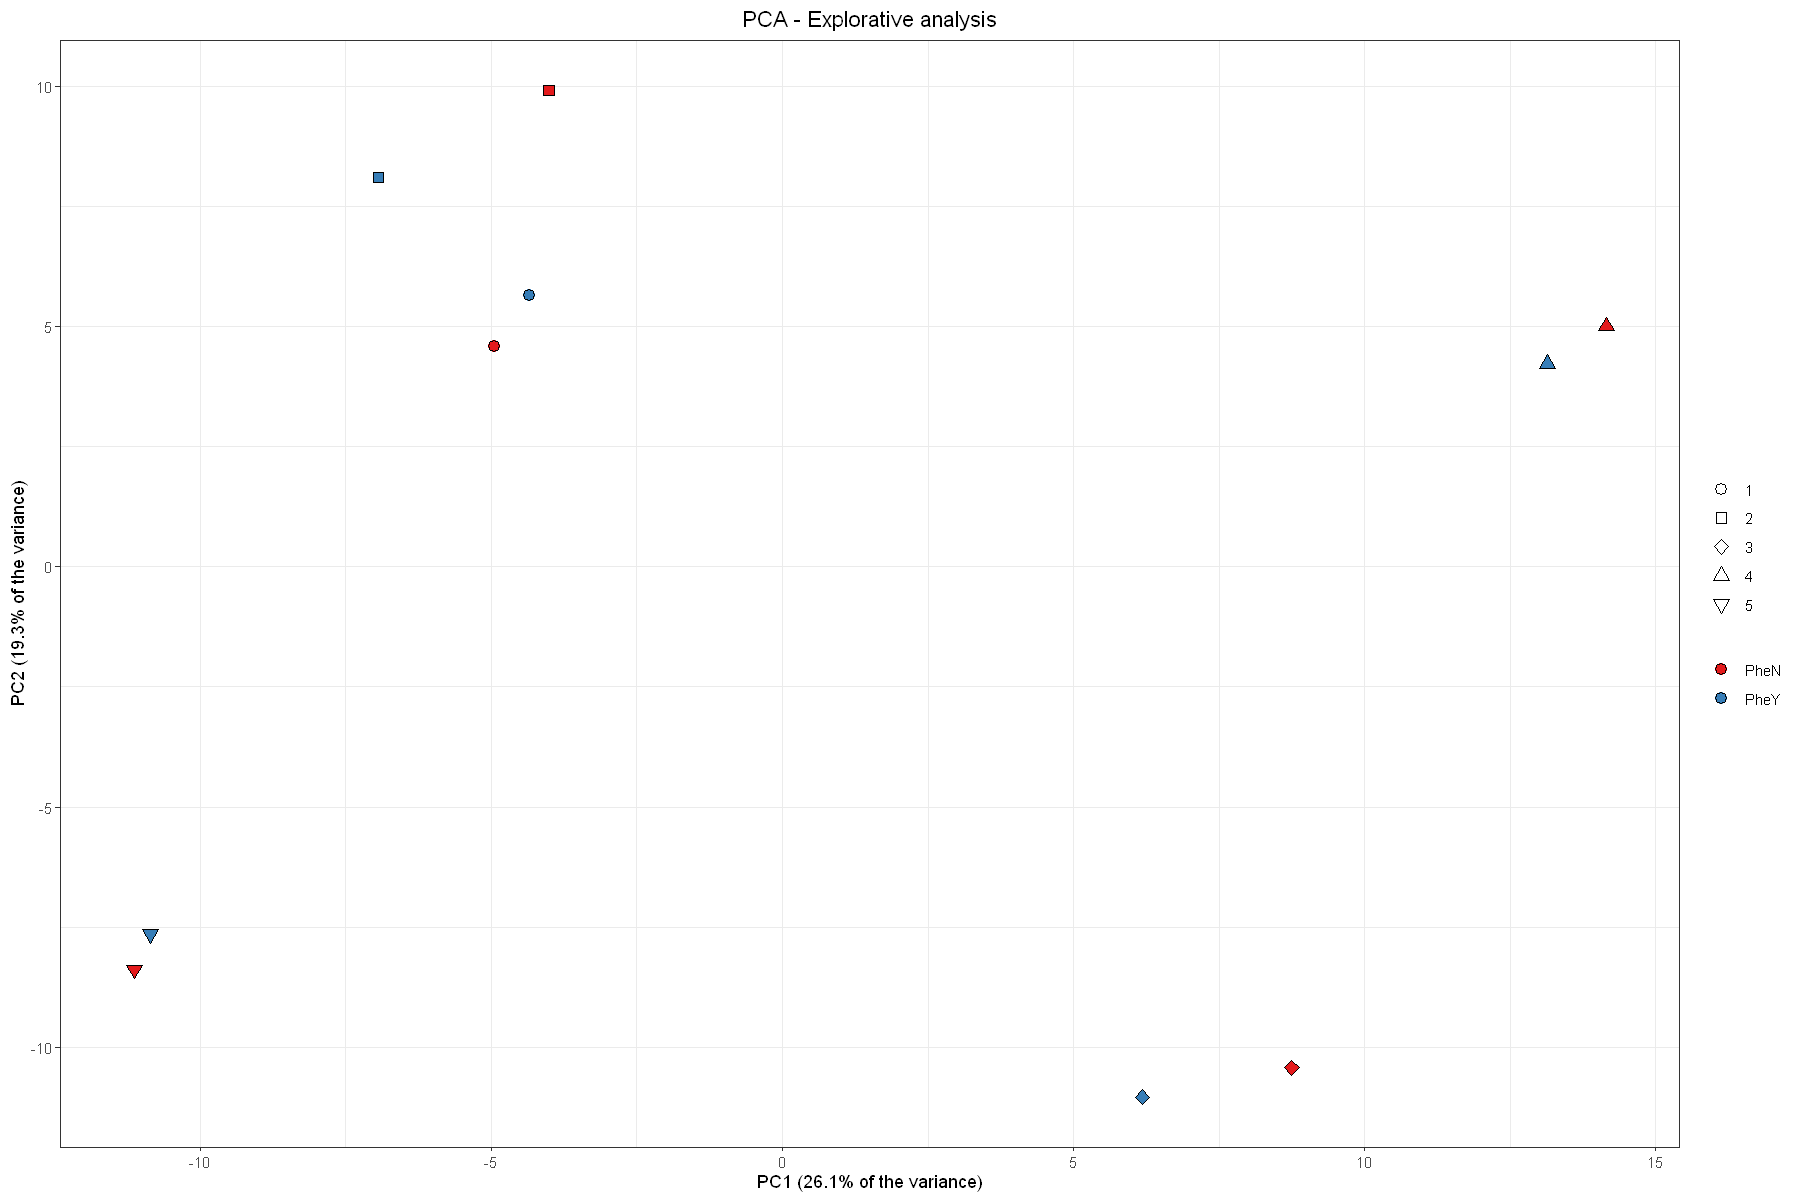

In [ ]:
#Normalizing
vsd <- vst(dds, blind = TRUE)  

counts_norm <- assay(vsd)
#Removing genes with variance equal to 0
counts_norm <- counts_norm[rowVars(counts_norm) != 0, ]

#Transposing it to "prcomp" format
counts_norm_matrix <- t(counts_norm)


#PCA:
pca <- prcomp(counts_norm_matrix)
summary(pca)

#Preparing the graph: PCA1 vs PCA2
pca_scores <- as.data.frame(pca$x[, 1:2])
pca_scores$Sample <- rownames(pca_scores)
rownames(pca_scores) <- NULL
#Adding groups
metadata_pca <- metadata
metadata_pca$Sample <- rownames(metadata_pca)
rownames(metadata_pca) <- NULL
pca_scores <- pca_scores %>% left_join(metadata_pca[, c("Sample", "PheTreatment", "Donor")], by = "Sample") 

#Plotting the graph: PC1 vs PC2
ggplot(pca_scores, aes(x = PC1, y = PC2, fill = PheTreatment, shape=Donor)) +
  geom_point(size = 3) +               
  labs(title = "PCA - Explorative analysis",
       x = paste0("PC1 (", round(100 * summary(pca)$importance[2,1], 1), "% of the variance)"),
       y = paste0("PC2 (", round(100 * summary(pca)$importance[2,2], 1), "% of the variance)")) +
  theme_bw() +
  theme(legend.title = element_blank(),
        plot.title = element_text(hjust = 0.5)) +
  scale_shape_manual(values=21:25) +
  scale_fill_brewer(palette="Set1") +
  guides(fill = guide_legend(override.aes = list(shape = 21)))

The PCA clearly shows consistent clustering by sample donor. This is expected, as biological differences among individuals can have important weight on the analysis. This finding opens several considerations:
- It confirms the need for a paired design (by donor) for the differential expression analysis, as outlined at the beginning.
- It suggests that phenylalanine treatment might have an overall modest effect on gene expression. The alternative explanation (that inter-donor variability is extremely high) is possible but less likely. It is therefore reasonable to consider more marginal effects and findings within the scope of this analysis.
- It raises considerations around a possible batch effect. It is possible that some experimental procedures were carried out separately for each donor (for organizational reasons), thus confounding biological variability with technical variability. Unfortunately, no batch information is available for this dataset, making it impossible to further assess this. If available, it would be important to include it in the statistical model. This should be kept in mind when interpreting further results.

### t-SNE

This should be considered as a simple exercise, as for this experimental setup — 
a bulk RNA-Seq with only 10 samples — t-SNE does not perform well and is redundant with PCA.  
It is however included as part of a more generalized pipeline.

Performing PCA
Read the 10 x 10 data matrix successfully!
OpenMP is working. 1 threads.
Using no_dims = 2, perplexity = 3.000000, and theta = 0.500000
Computing input similarities...
Building tree...
Done in 0.00 seconds (sparsity = 0.900000)!
Learning embedding...
Iteration 50: error is 56.128122 (50 iterations in 0.00 seconds)
Iteration 100: error is 80.210168 (50 iterations in 0.00 seconds)
Iteration 150: error is 51.413402 (50 iterations in 0.00 seconds)
Iteration 200: error is 56.953414 (50 iterations in 0.00 seconds)
Iteration 250: error is 57.276417 (50 iterations in 0.00 seconds)
Iteration 300: error is 0.813709 (50 iterations in 0.00 seconds)
Iteration 350: error is 0.494480 (50 iterations in 0.00 seconds)
Iteration 400: error is 0.081740 (50 iterations in 0.00 seconds)
Iteration 450: error is 0.054810 (50 iterations in 0.00 seconds)
Iteration 500: error is 0.026130 (50 iterations in 0.00 seconds)
Iteration 550: error is 0.023078 (50 iterations in 0.00 seconds)
Iteration 600: 

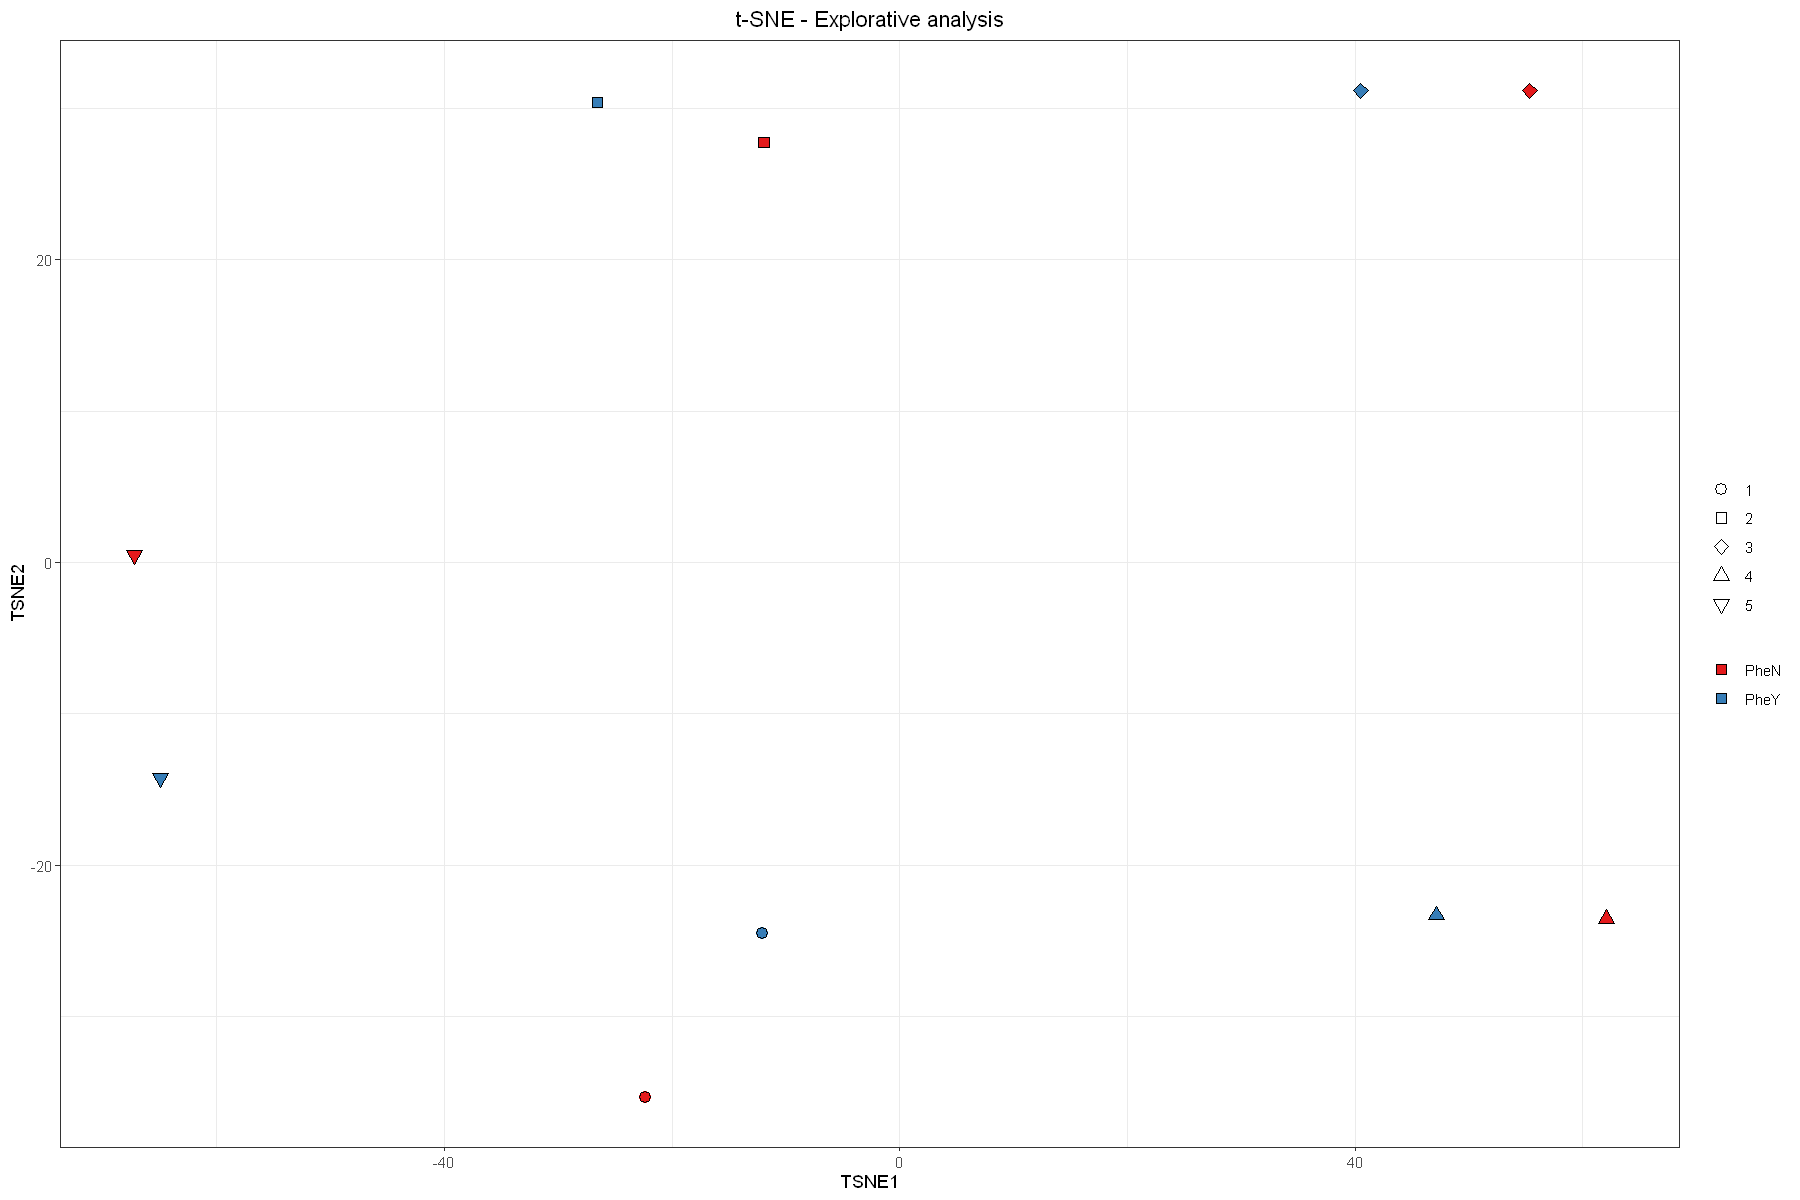

In [ ]:
#t-SNE:
tsne <- Rtsne(counts_norm_matrix, dims = 2, perplexity = 3, verbose = TRUE, max_iter = 1000) #Choosing perplexity for t-SNE according to the formula: perplexity <= min{(N_samples/3)-1, 30}

tsne_scores <- as.data.frame(tsne$Y)
colnames(tsne_scores) <- c("TSNE1", "TSNE2")
tsne_scores$Sample <- rownames(counts_norm_matrix)

#Adding groups
tsne_scores <- tsne_scores %>% left_join(metadata_pca[, c("Sample", "PheTreatment", "Donor")], by = "Sample") 

#Plotting the graph: TSNE1 vs TSNE2:
ggplot(tsne_scores, aes(x = TSNE1, y = TSNE2, fill = PheTreatment, shape=Donor)) +
  geom_point(size = 3) +             
  labs(title = "t-SNE - Explorative analysis",
       x = paste0("TSNE1"),
       y = paste0("TSNE2")) +
  theme_bw() +
  theme(legend.title = element_blank(),
        plot.title = element_text(hjust = 0.5)) +
  scale_shape_manual(values=21:25) +
  scale_fill_brewer(palette="Set1") +
  guides(fill = guide_legend(override.aes = list(shape = 22)))

The same conclusions found from the PCA can be assessed from this figure.  
It is important to stress t-SNE has much less value for this specific project setup.

### Heatmap

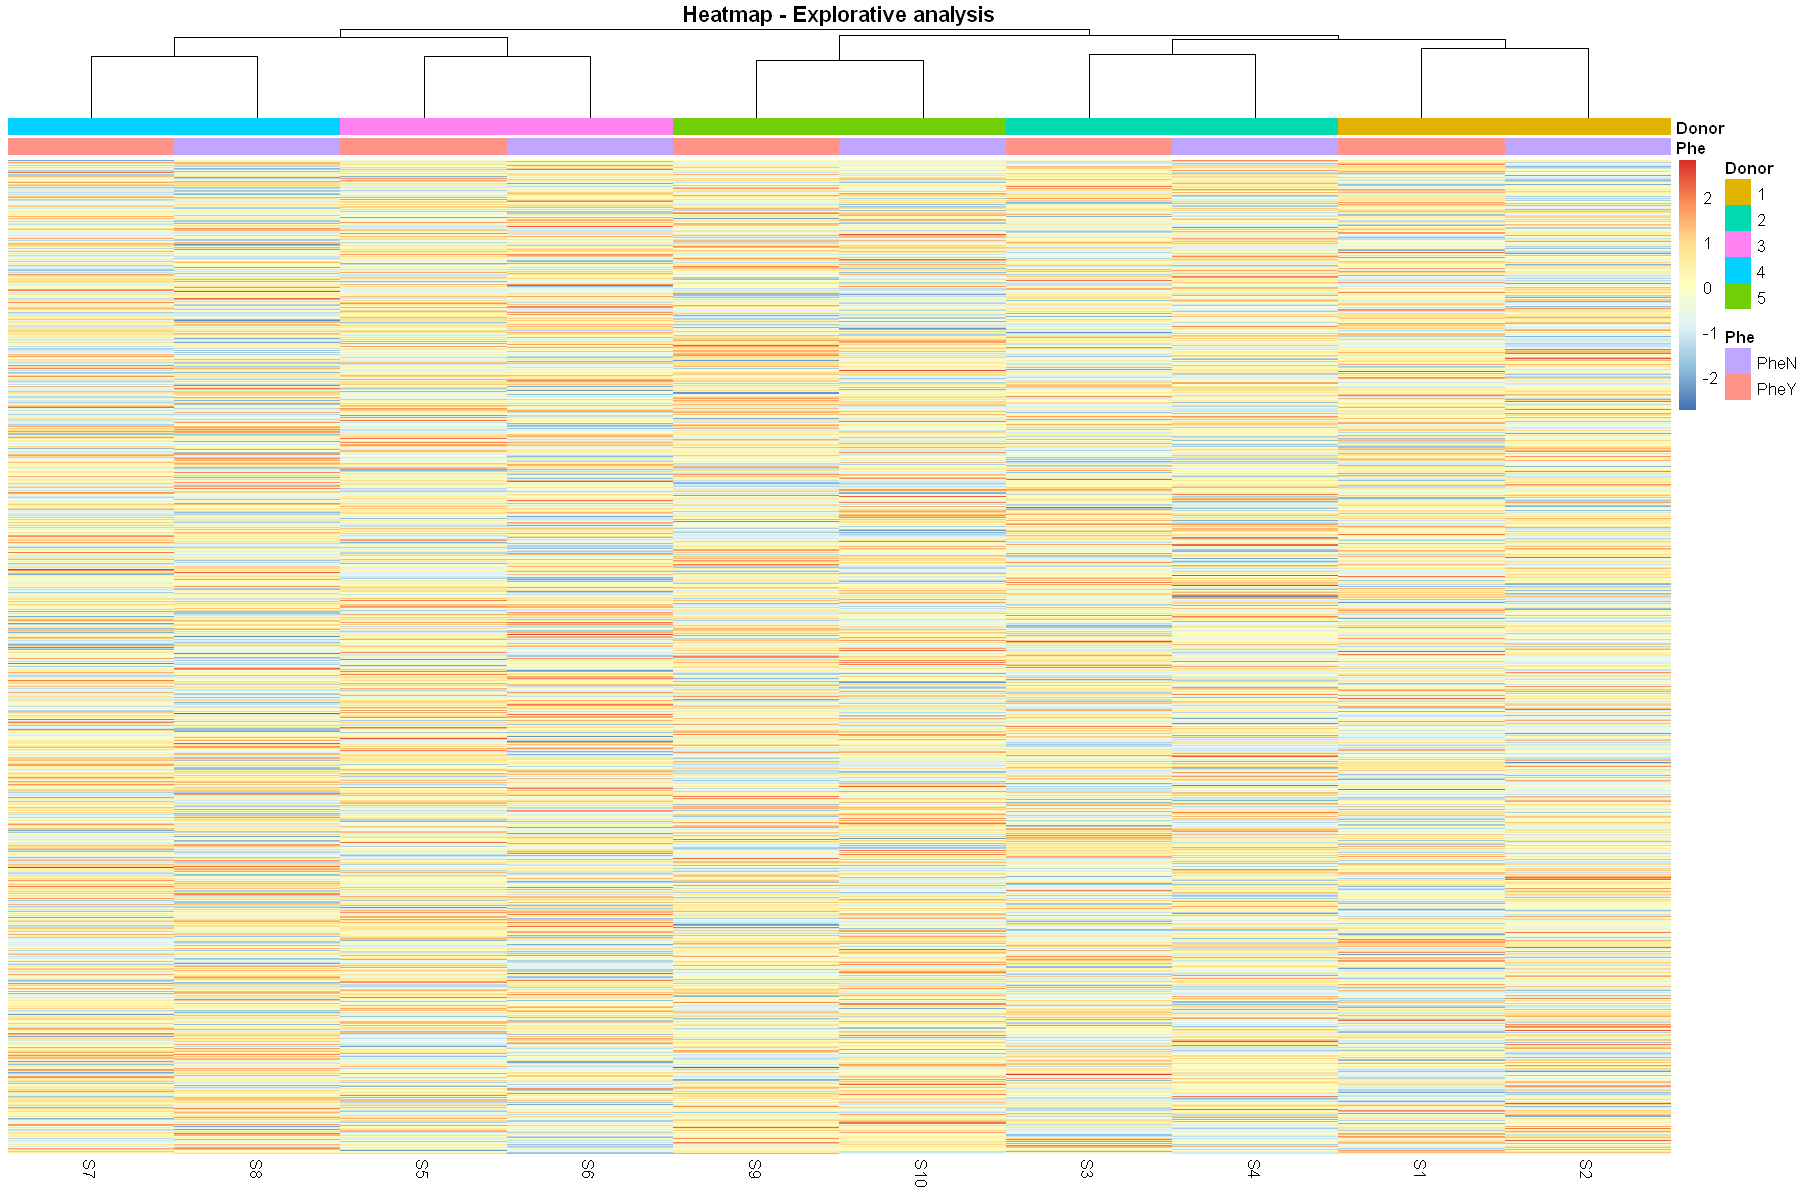

In [ ]:
#Obtaining z-scores:
counts_norm_matrix_scaled <- scale(counts_norm_matrix)
#The pheatmap function requires samples to be in columns. Transposing the matrix:
heatmap_matrix <- t(counts_norm_matrix_scaled)

Conditions <- data.frame(
  Phe  = metadata$PheTreatment,
  Donor = metadata$Donor
)
rownames(Conditions) <- rownames(metadata)

pheat <- pheatmap(heatmap_matrix,
                  cluster_rows = FALSE, 
                  cluster_cols = TRUE,
                  annotation_col = Conditions,
                  show_rownames = FALSE,
                  show_colnames = TRUE,
                  main = "Heatmap - Explorative analysis")

The heatmap confirms the findings of the PCA, with strong clustering by donor as opposed to phenylalanine treatment.  
Additionally, no sample shows any particular expression profile that would raise concerns about it being an outlier.

## Section 3: Differential Expression analysis

Results extraction and considerations: Analysis on "PheTreatment".

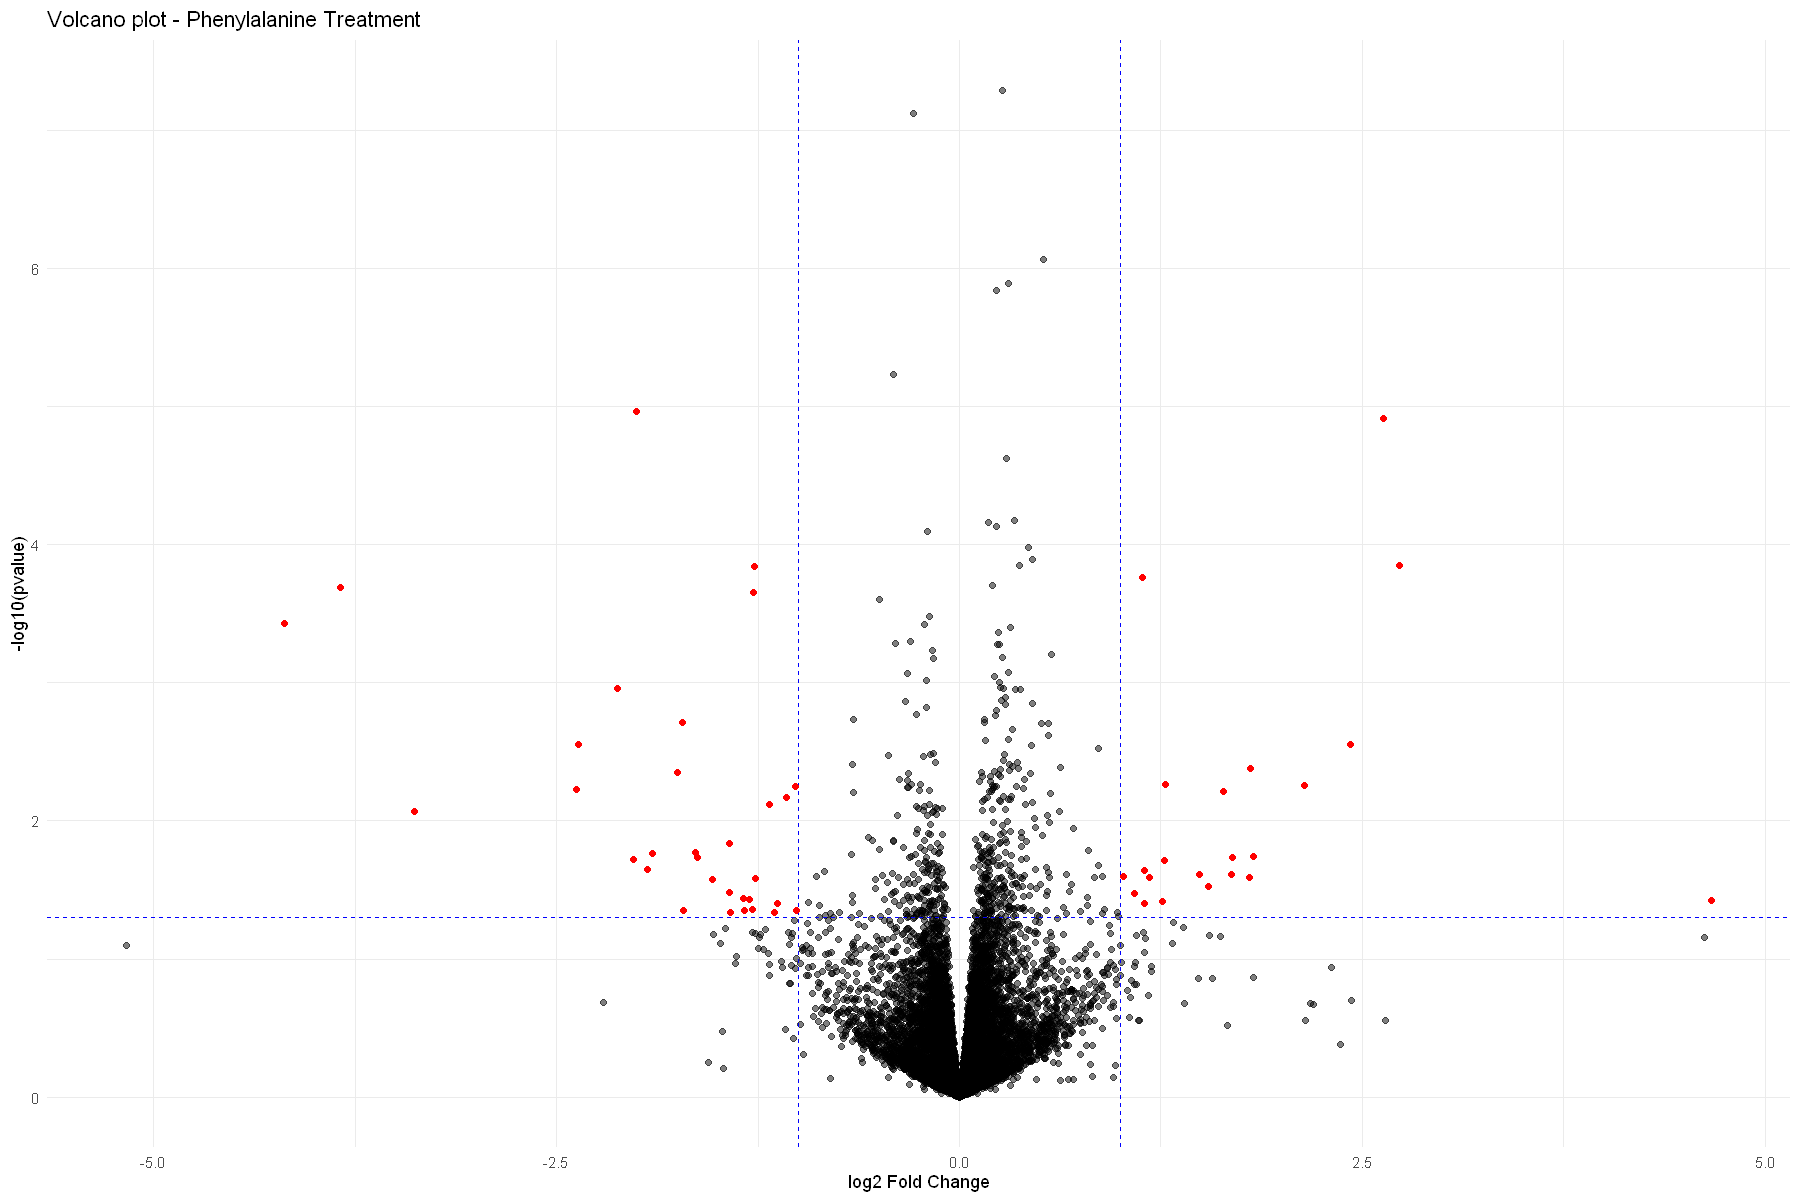

In [ ]:
res_phe <- results(dds, contrast=c("PheTreatment","PheY","PheN"))
res_phe_df <- as.data.frame(res_phe)

#Volcano plot
ggplot(res_phe_df, aes(x = log2FoldChange, y = -log10(pvalue))) +
  geom_point(alpha=0.5) +
  geom_hline(yintercept=-log10(0.05), linetype="dashed", color="blue") +
  geom_vline(xintercept=c(-1,1), linetype="dashed", color="blue") +
  geom_point(data=res_phe_df[res_phe_df$pvalue<0.05 & abs(res_phe_df$log2FoldChange)>1, ],
             color="red") +
  theme_minimal() +
  labs(title="Volcano plot - Phenylalanine Treatment", x="log2 Fold Change", y="-log10(pvalue)")

The volcano plot shows a reasonable profile for the contrast on phenylalanine treatment.  
Raw p-value was used as the visualization threshold to display the full set of genes considered for the following functional enrichment analyses. However it is important to note that adjusted (and not raw) p-value was used as the primary significance criterion for identifying differentially expressed genes.  
<br>
Now selecting significant differentially expressed genes, by raw and adjusted p-value:

In [ ]:
#Transforming ENSEMBL names in SYMBOL
res_phe_df$ENSEMBL <- rownames(res_phe_df)
res_phe_df <- merge(res_phe_df, gene_map,
                   by.x = "ENSEMBL",
                   by.y = "ensembl_gene_id",
                   all.x = TRUE)

#Selecting the DE genes:
#by raw p-value: 549 differentially expressed genes
res_phe_sig <- res_phe_df %>% filter(pvalue < 0.05)
#by adjusted p-value: 9 differentially expressed genes
res_phe_sig_padj <- res_phe_df %>% filter(padj < 0.05)


#Selecting the top 50 upregulated genes
top_up <- res_phe_sig[res_phe_sig$log2FoldChange > 0, ]
top_up <- top_up[order(top_up$log2FoldChange, decreasing = TRUE), ]
top50_up <- head(top_up, 50)
#Selecting the top 50 downregulated genes
top_down <- res_phe_sig[res_phe_sig$log2FoldChange < 0, ]
top_down <- top_down[order(top_down$log2FoldChange), ]
top50_down <- head(top_down, 50)

Creating heatmaps of top up and downregulated genes:

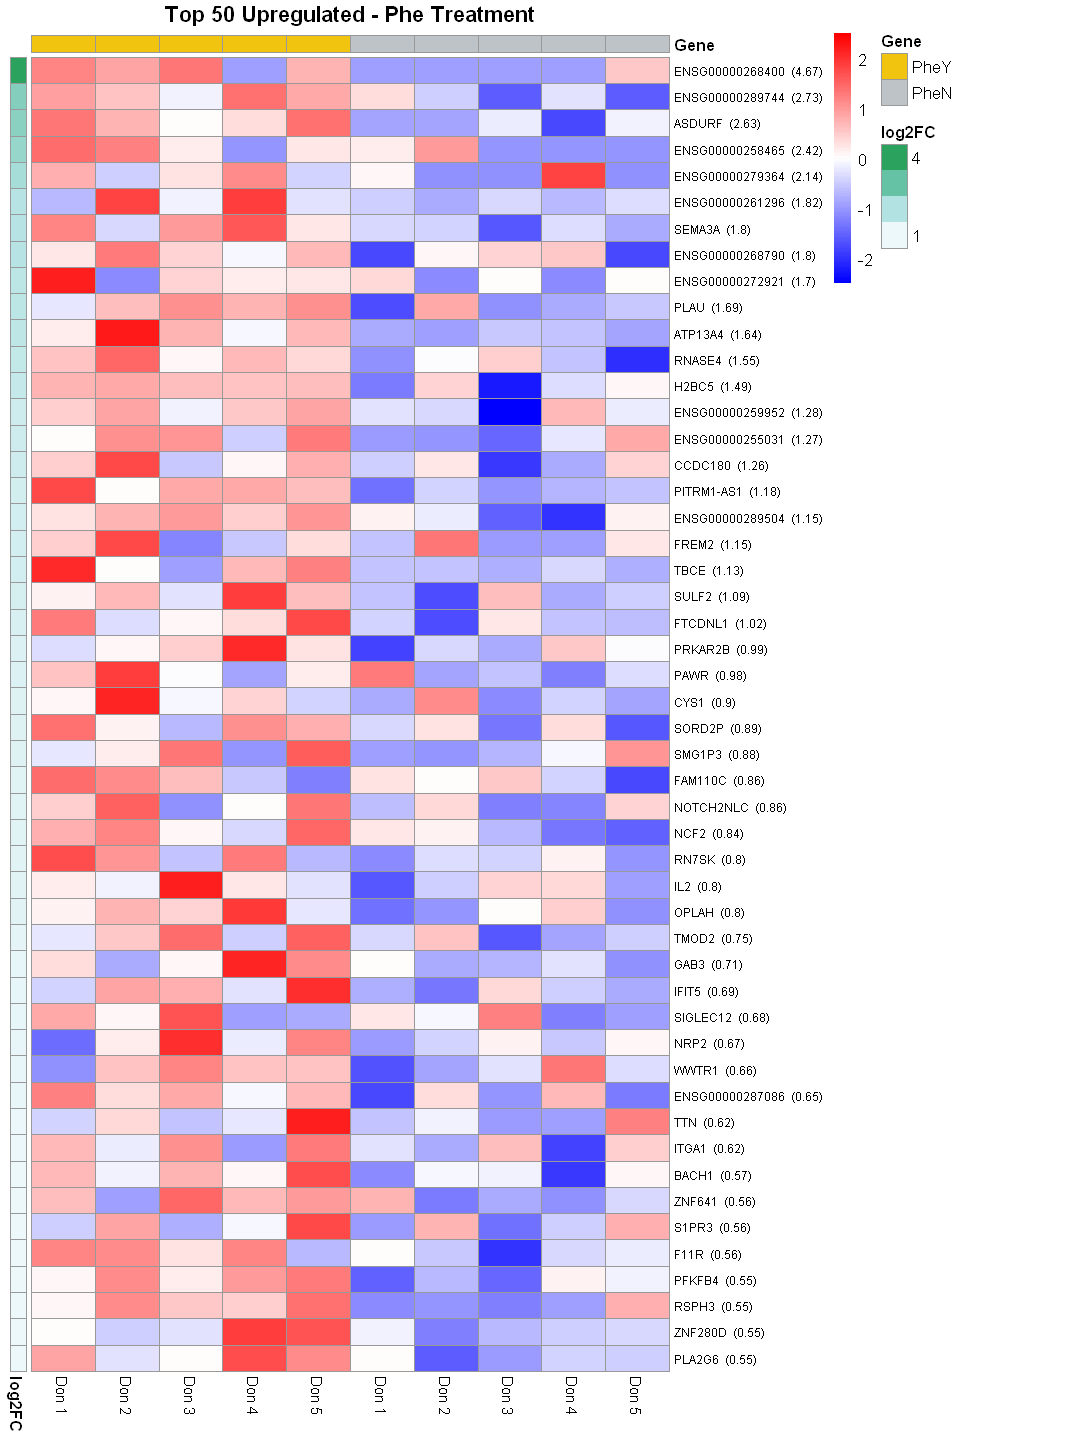

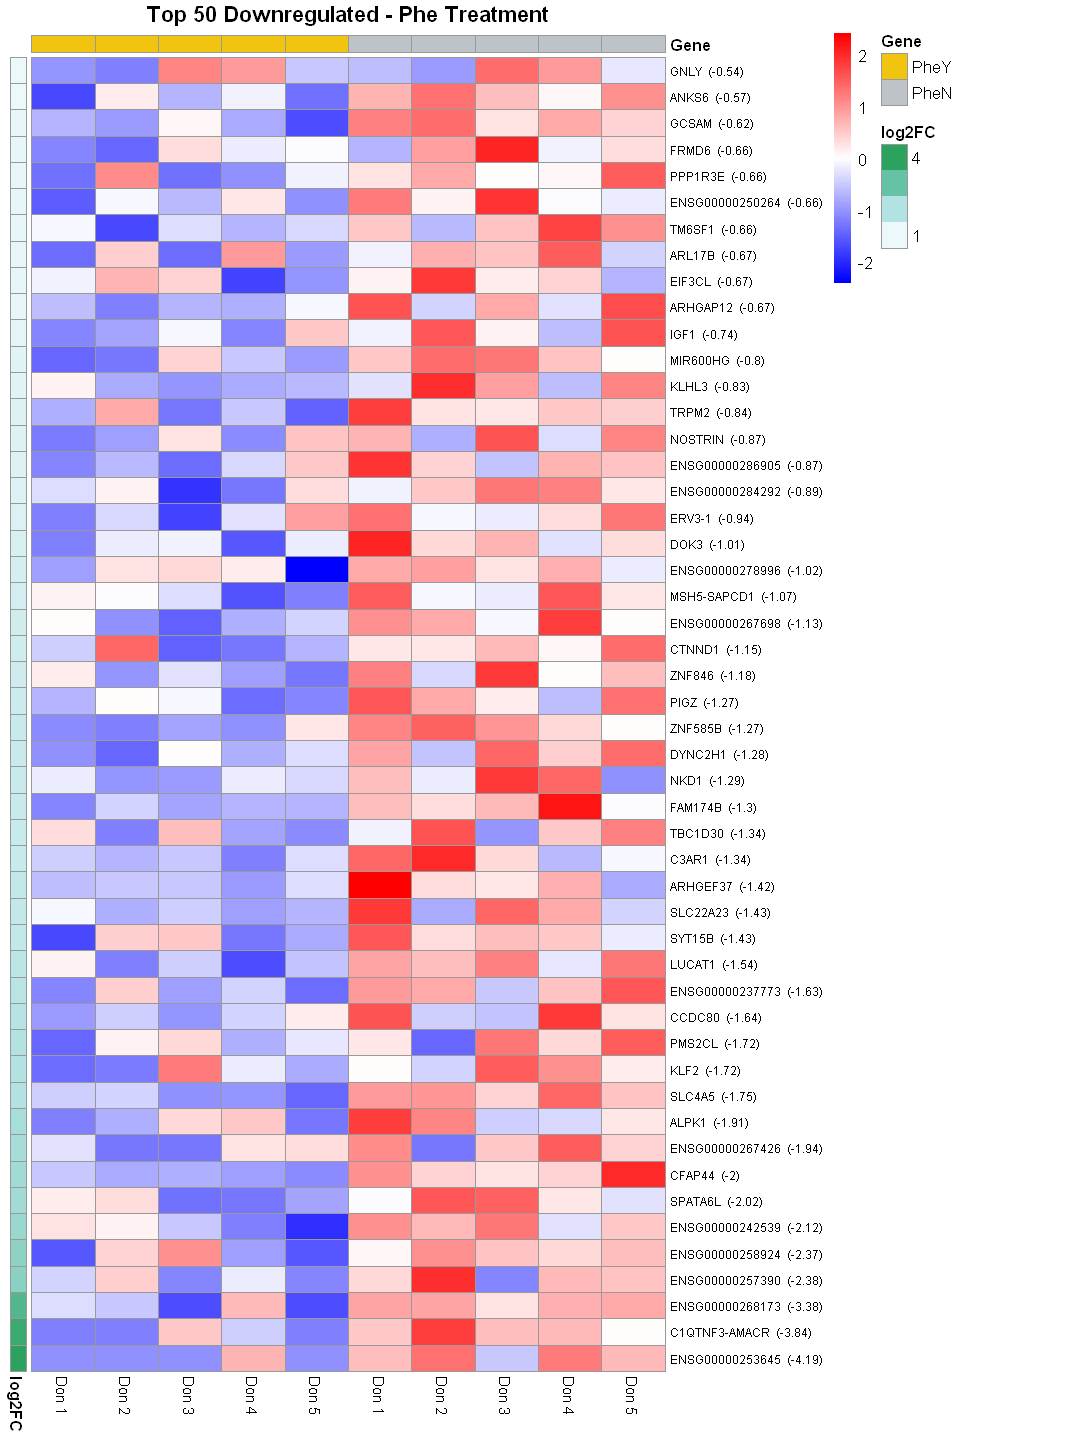

In [ ]:
# TOP 50 UPREGULATED
# Sorting by fold change (decreasing)
top50_up_ordered <- top50_up[order(top50_up$log2FoldChange, decreasing=TRUE), ]

vst_counts <- assay(vst(dds, blind = FALSE))  # This was done already for the PCA, but this time "blind = FALSE" is needed, as it is necessary for DE visualizations
# Extracting counts of top genes
up_mat <- vst_counts[top50_up_ordered$ENSEMBL, ]
rownames(up_mat) <- top50_up_ordered$gene_symbol 
col_names <- c("Don 1", "Don 2", "Don 3", "Don 4", "Don 5", "Don 1", "Don 2", "Don 3", "Don 4", "Don 5")

sample_order <- c("S1","S3","S5","S7","S9","S2","S4","S6","S8","S10")

# Heatmap features
col_annotation <- data.frame(
  Gene = factor(c(rep("PheY", 5), rep("PheN", 5)))
)
rownames(col_annotation) <- sample_order

ann_colors <- list(
  Gene = c("PheY" = "#F1C40F", "PheN" = "#BDC3C7")
)

row_annotation_up <- data.frame(
  log2FC = top50_up_ordered$log2FoldChange,
  row.names = rownames(up_mat)
)

gene_labels <- paste0(rownames(up_mat), 
                      "  (", round(top50_up_ordered$log2FoldChange, 2), ")")

#Changing visualization options:
options(repr.plot.width = 9, repr.plot.height = 12)

# Up heatmap graph
pheatmap(up_mat[, sample_order],
         cluster_rows = FALSE,
         cluster_cols = FALSE,
         scale = "row",
         main = "Top 50 Upregulated - Phe Treatment",
         color = colorRampPalette(c("blue", "white", "red"))(100),
         annotation_col = col_annotation,
         annotation_row = row_annotation_up,
         annotation_colors = ann_colors,
         labels_row = gene_labels, 
         labels_col = col_names,
         fontsize_row = 7,
         fontsize_col = 9)



# TOP 50 DOWNREGULATED 
# Sorting by fold change
top50_down_ordered <- top50_down[order(top50_down$log2FoldChange, decreasing=TRUE), ]

#Extracting counts of top genes
down_mat <- vst_counts[top50_down_ordered$ENSEMBL, ]
rownames(down_mat) <- top50_down_ordered$gene_symbol 

# Heatmap features
col_annotation <- data.frame(
  Gene = factor(c(rep("PheY", 5), rep("PheN", 5)))
)
rownames(col_annotation) <- sample_order

ann_colors <- list(
  Gene = c("PheY" = "#F1C40F", "PheN" = "#BDC3C7")
)

row_annotation_down <- data.frame(
  log2FC = abs(top50_down_ordered$log2FoldChange),  # abs value: So colors are darker for lower log2FC
  row.names = rownames(down_mat)
)

gene_labels <- paste0(rownames(down_mat), 
                      "  (", round(top50_down_ordered$log2FoldChange, 2), ")")

# Down heatmap graph
pheatmap(down_mat[, sample_order],
         cluster_rows = FALSE,
         cluster_cols = FALSE,
         scale = "row",
         main = "Top 50 Downregulated - Phe Treatment",
         color = colorRampPalette(c("blue", "white", "red"))(100),
         annotation_col = col_annotation,
         annotation_row = row_annotation_down,
         annotation_colors = ann_colors,
         labels_row = gene_labels,
         labels_col = col_names,
         fontsize_row = 7,
         fontsize_col = 9)

In conclusion, this is what resulted from the DESeq2 statistical analysis:
- 9 differentially expressed genes by adjusted p-value. Such a low number confirms that Phe treatment has a subtle effect on gene expression.  
These genes are: KMT2C, GZMB, LPIN2, AHNAK, IL3, RAB8B, RBPJ, CFAP44, ASDURF.   
- 549 differentially expressed genes by raw p-value. The top genes in this group are shown in the heatmaps.

Looking at these graphs, something interesting is the high proportion of genes lacking HUGO symbols at the extremes of the heatmaps (which is where log2 fold changes are most pronounced). A quick database search reveals that these genes correspond to uncharacterized, novel, or non-coding RNA transcripts.  
The overrepresentation of these transcripts among DE genes with strong log2FC values may reflect several factors:
- Uncharacterized and ncRNA transcripts often have low baseline expression. As a result, even small absolute changes can translate into high fold changes, potentially inflating their apparent significance.
- The modulatory effects of phenylalanine on immune pathways are poorly studied. Thus, genes involved in its metabolic or regulatory effects may lack detailed annotation in public databases.
- Also, phenylalanine may induce subtle transcriptional changes overall. In this case, the most statistically significant genes could belong to secondary pathways, while primary targets (if any) might not reach significance due to mild effect sizes.
Functional Enrichment analysis will provide more insights into these hypotheses. Still, it is important to account for possible biases due to low baseline expression levels. Indeed, a parallel analysis incorporating a log2FC shrinkage can be later considered to address this problem.

From these findings, it might be good to proceed with the functional enrichment analysis on three parallel tracks:
- The 9 genes identified with adjusted p-value are too few for a meaningful Functional Enrichment (FE) analysis. They should instead be studied individually through literature or databases to identify the biological processes and pathways they are involved in, and to draw conclusions/hypotheses on the effect of phenylalanine treatment. These genes represent the most relevant and informative results of this analysis.
- ORA Functional Enrichment analysis on the 549 genes significantly differentially expressed by raw p-value. However, it is important to keep in mind that the results obtained from this analysis will be relatively weak and should be interpreted with caution.  
- GSEA Functional Enrichment analysis on all the genes. These results will be stronger than the ORA results, but must be carefully interpreted.

If any overlap is found between the results obtained in the three cases, it can be interpreted as a strong and reliable signal.

# *Module C: Functional Enrichment analysis*

## DE genes by adjusted p-value

Performing a FE analysis through literature study of the 9 genes that passed the threshold for adj p-value

As previously shown, the 9 significantly DE genes for adjusted p-value are: KMT2C, GZMB, LPIN2, AHNAK, IL3, RAB8B, RBPJ, CFAP44, ASDURF.   
First, functional interactions within this group of genes were observed using String. The obtained network does not have significantly more interactions than expected, but this is reasonable, as for a group of only 9 genes this kind of statistic has very little meaning. Rather, 9 interactions were found while only 3 were expected, which is evidence of the presence of at least a partial correlation between the genes in the network.   
Indeed, the image shows a network comprising IL3, GZMB, RBPJ, KMT2C, AHNAK. A quick search in the literature shows that four of these (KMT2C, RBPJ, AHNAK, IL3) are involved in cellular differentiation, along with another gene not included in the String network, LPIN2. Moreover, the most strongly enriched pathway on String is "NOTCH2 intracellular domain regulates transcription" (especially relevant for GZMB and RBPJ, but also KMT2C and AHNAK are involved in this), which is crucial for cell differentiation. Therefore, at least 6/9 among these genes are involved in cell differentiation.

<img src="https://raw.githubusercontent.com/pierpaolo-cantisani/RNA-Seq-analysis/main/images/string.png" alt="String network" width="1200">

Further literature research shows that GZMB, IL3, and RBPJ are strongly involved in the immune response (not particularly relevant, since the sequencing was done on Th2 cells), and KMT2C and RBPJ are involved in epigenetic and transcriptional regulation. KMT2C, GZMB, AHNAK, and RBPJ are associated with leukemia, which is not surprising given their involvement in differentiation, along with RAB8B, which has instead specific functions in vesicular traffic.  
CFAP44 and ASDURF seem to be the most functionally isolated genes in this group. CFAP44 is a ciliary component, and is associated with motility and migration. ASDURF is instead related to renal and liver metabolism.

## ORA and GSEA

Two different FE analyses are performed:
- Over Representation Analysis (ORA) : on the 549 genes that passed the threshold for raw p-value.
- Gene Set Enrichment Analysis (GSEA).

### **ORA:**

[1] 518

Warning message in fortify(object, showCategory = showCategory, by = x, ...):
"Arguments in `...` must be used.
✖ Problematic argument:
• by = x
ℹ Did you misspell an argument name?"
Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the enrichplot package.
  Please report the issue at
  <https://github.com/GuangchuangYu/enrichplot/issues>."


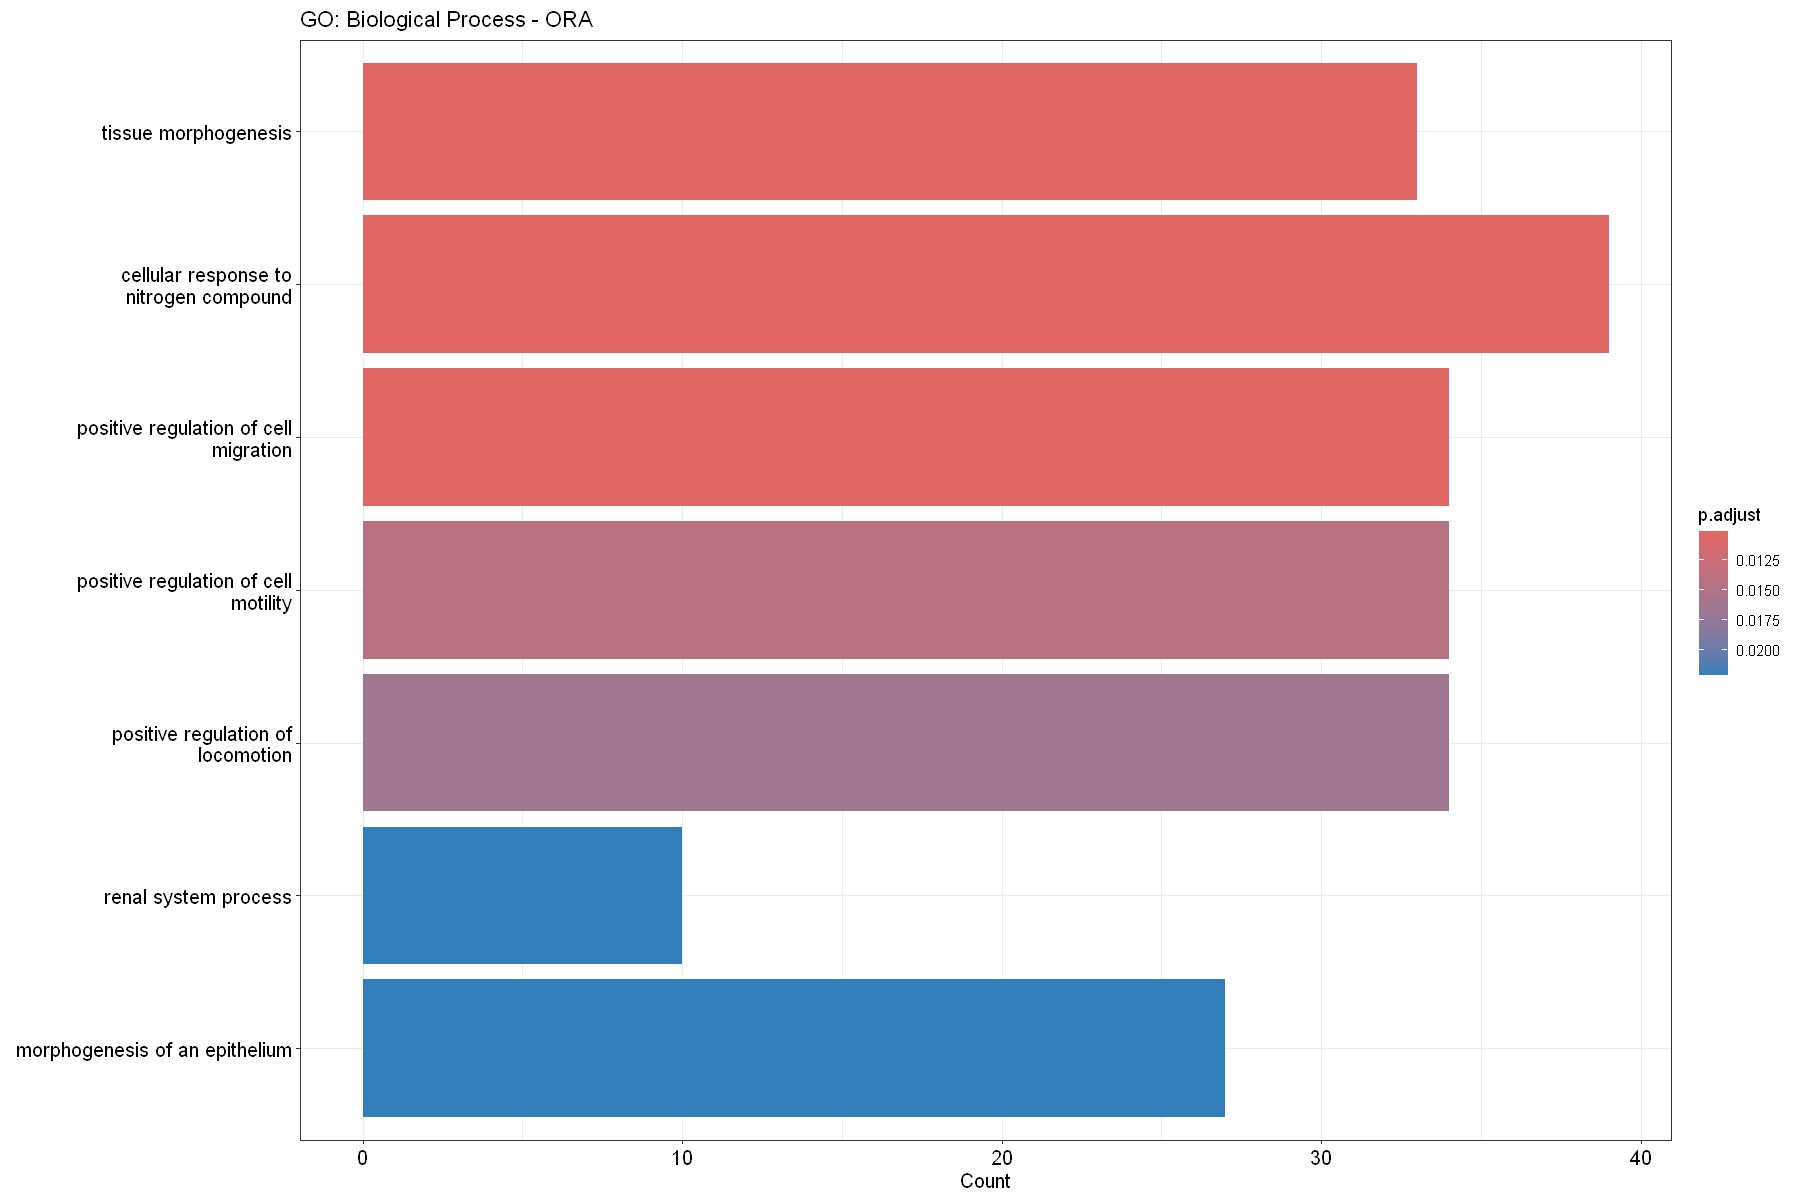

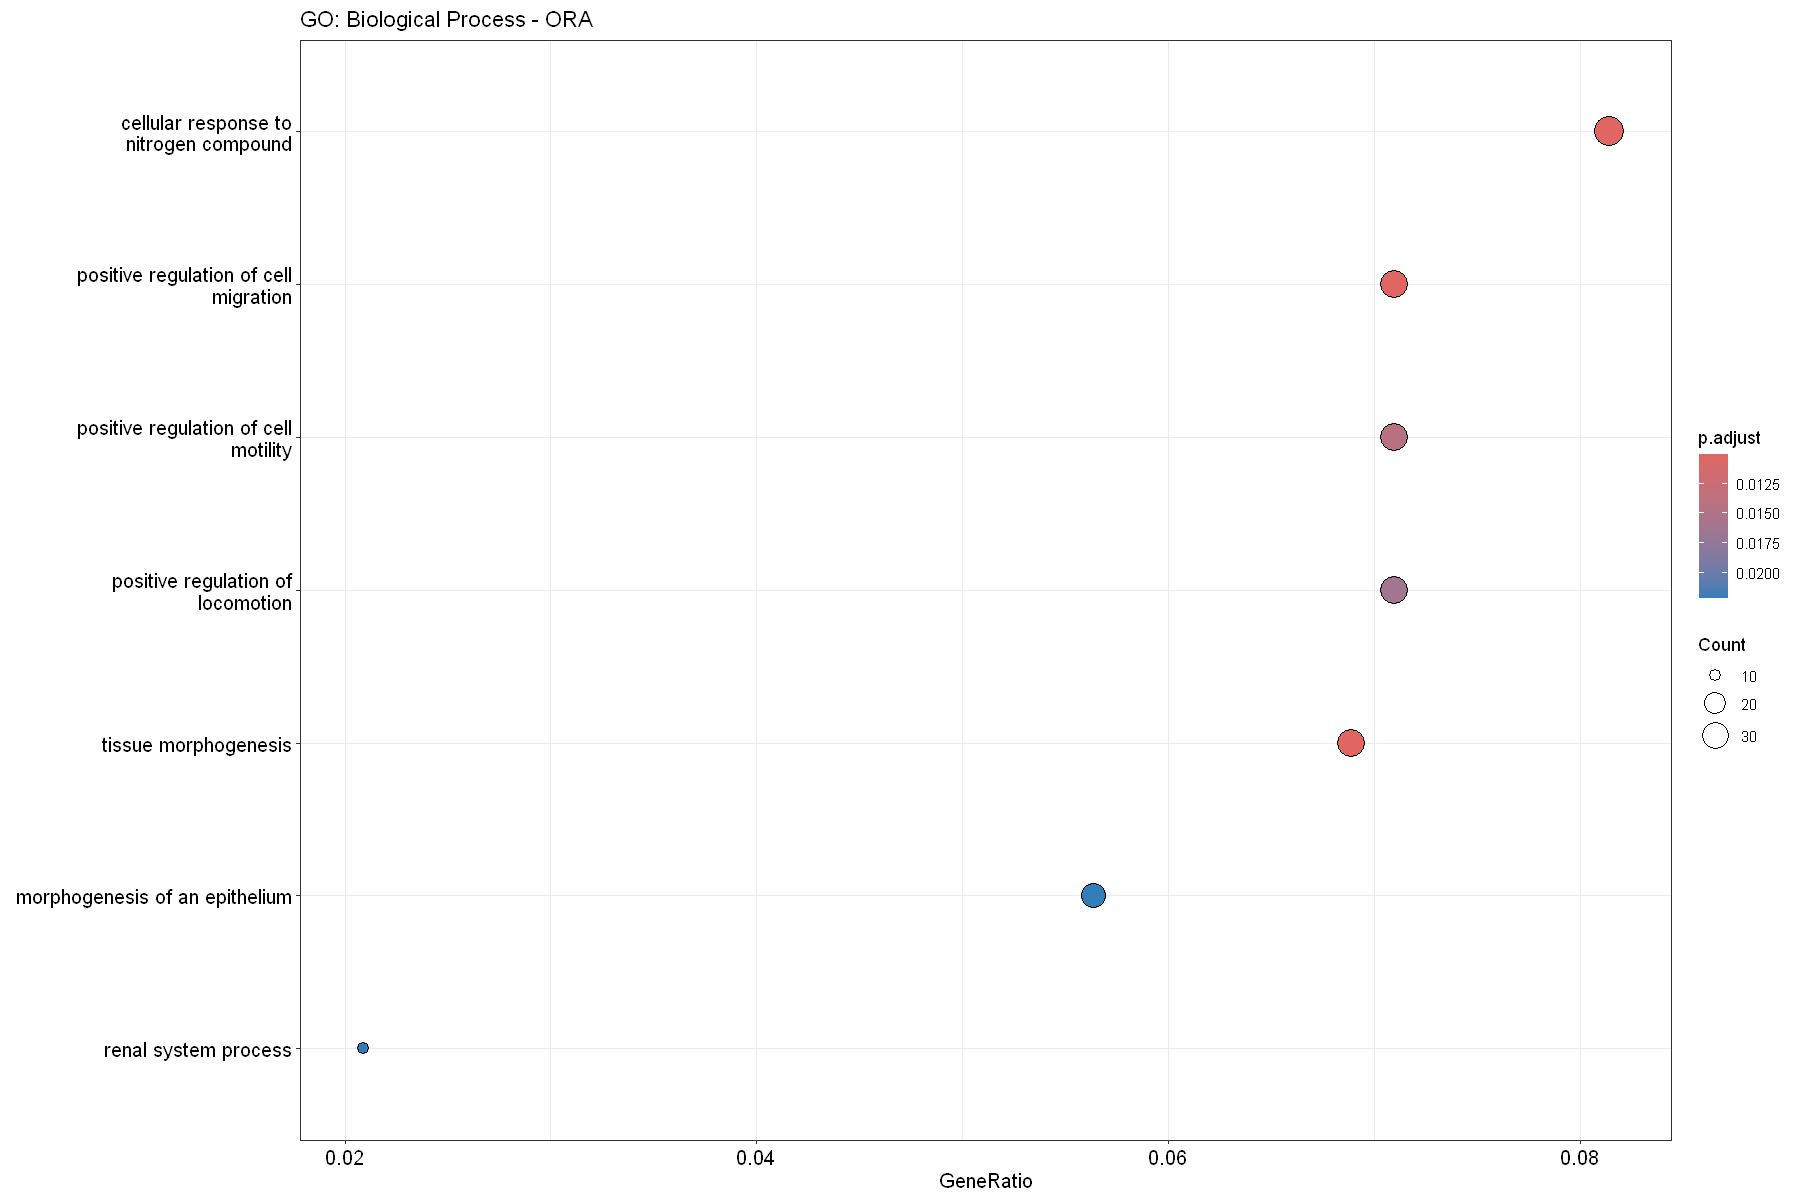

In [ ]:
#Using ClusterProfiler
#Cleaning the ENSEMBL names(cutting the version)
res_phe_df$ENSEMBL <- sub("\\..*$", "", res_phe_df$ENSEMBL) 
#Extracting SYMBOLS
background_sym <- res_phe_df$gene_symbol
sig_genes <- res_phe_sig$gene_symbol

# ORA
# Checking: SYMBOLs found in the database
all_symbols <- keys(org.Hs.eg.db, keytype = "SYMBOL")
mapped_symbols <- intersect(sig_genes, all_symbols)
length(mapped_symbols)        
# 518/549 SYMBOLs were found
background_sym <- intersect(background_sym, all_symbols)

ego_BP_sym <- enrichGO(
  gene          = sig_genes,        # Significant DE genes
  universe      = background_sym,   # Background: all genes analyzed from DEseq2
  OrgDb         = org.Hs.eg.db,             
  keyType       = "SYMBOL",                
  ont           = "BP",             # Biological Process
  pvalueCutoff =  0.05,
  qvalueCutoff =  0.2
)

#Changing graph visualization options:
options(repr.plot.width = 15, repr.plot.height = 10)

barplot(ego_BP_sym, showCategory = 10, title = "GO: Biological Process - ORA")
dotplot(ego_BP_sym, showCategory = 10, title = "GO: Biological Process - ORA")

### **GSEA**

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
"There are ties in the preranked stats (0.05% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results."
Warning message:
"`aes_()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`
ℹ The deprecated feature was likely used in the enrichplot package.
  Please report the issue at
  <https://github.com/GuangchuangYu/enrichplot/issues>."
Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the enrichplot package.
  Please report the issue at
  <https://github.com/GuangchuangYu/enrichplot/issues>."


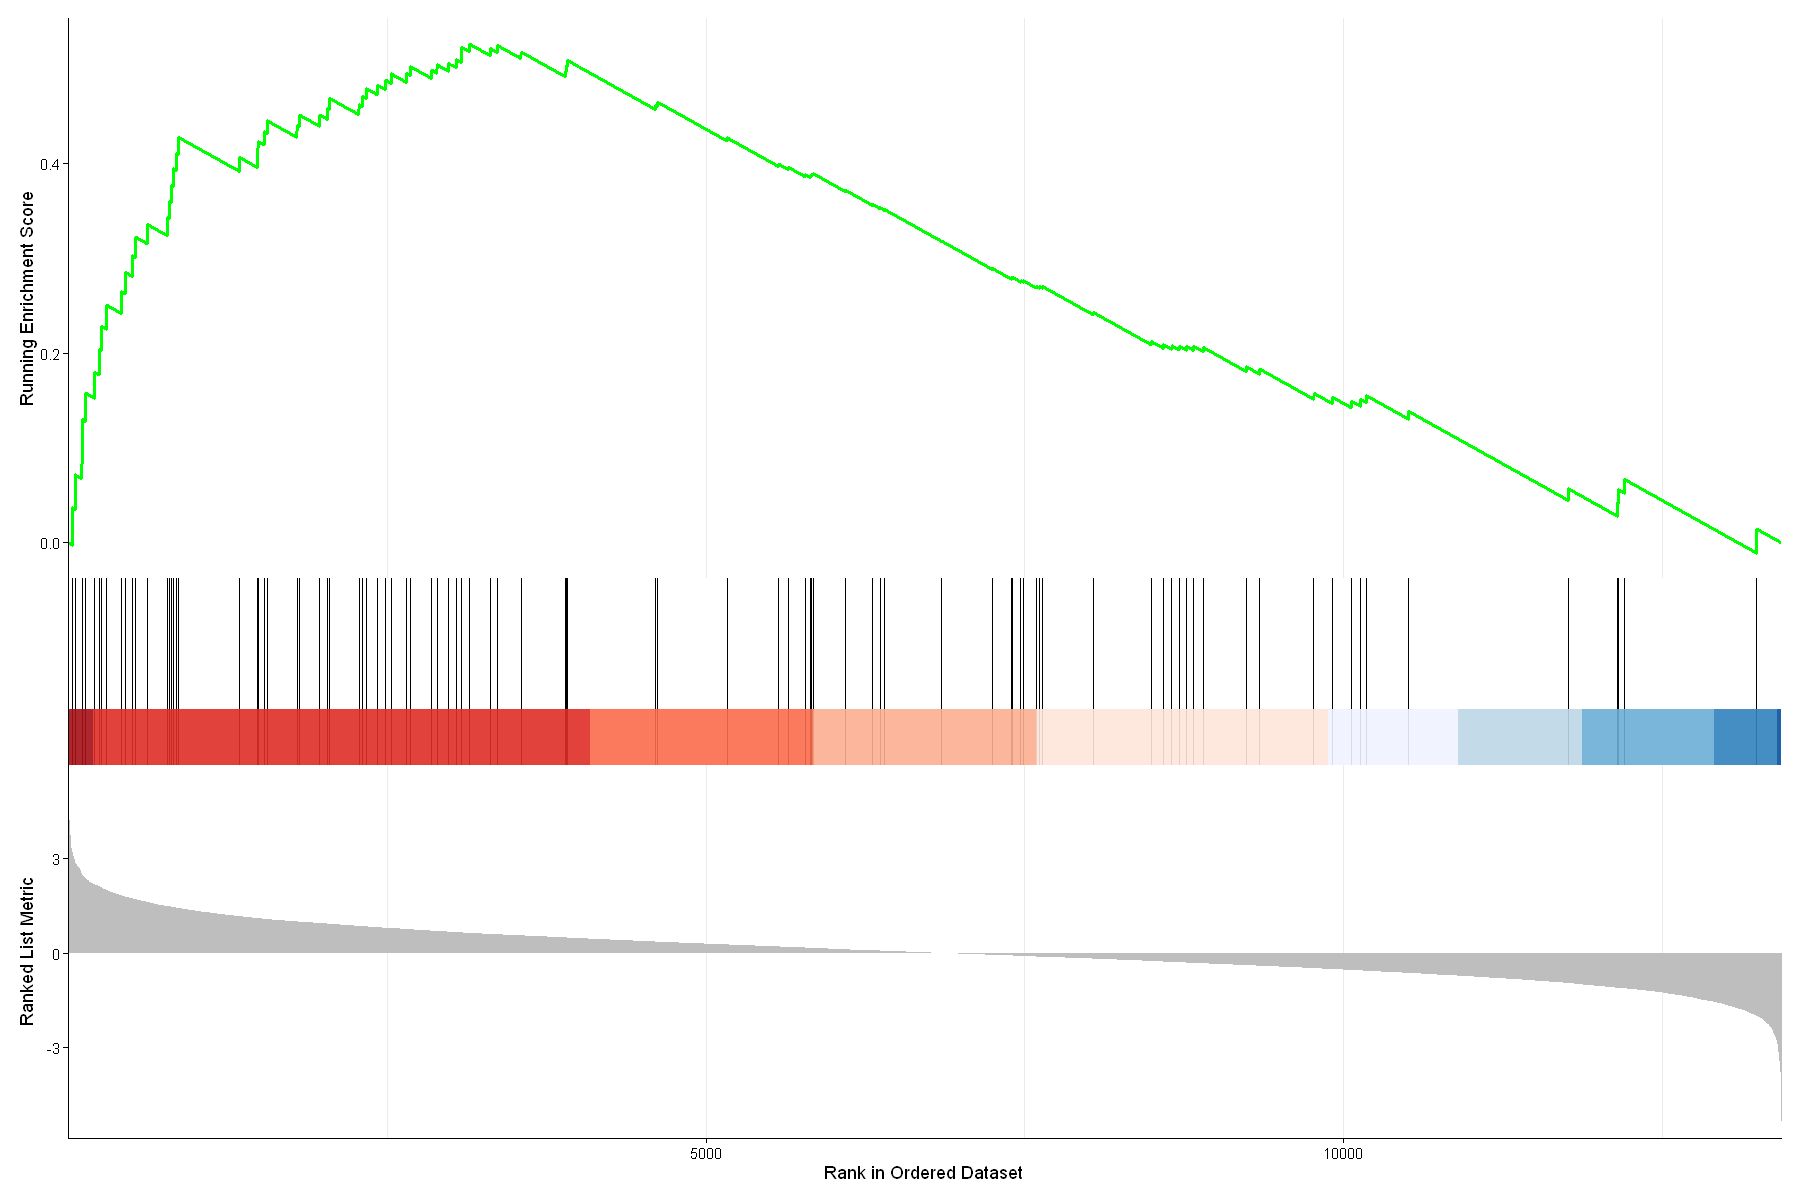

Picking joint bandwidth of 0.261



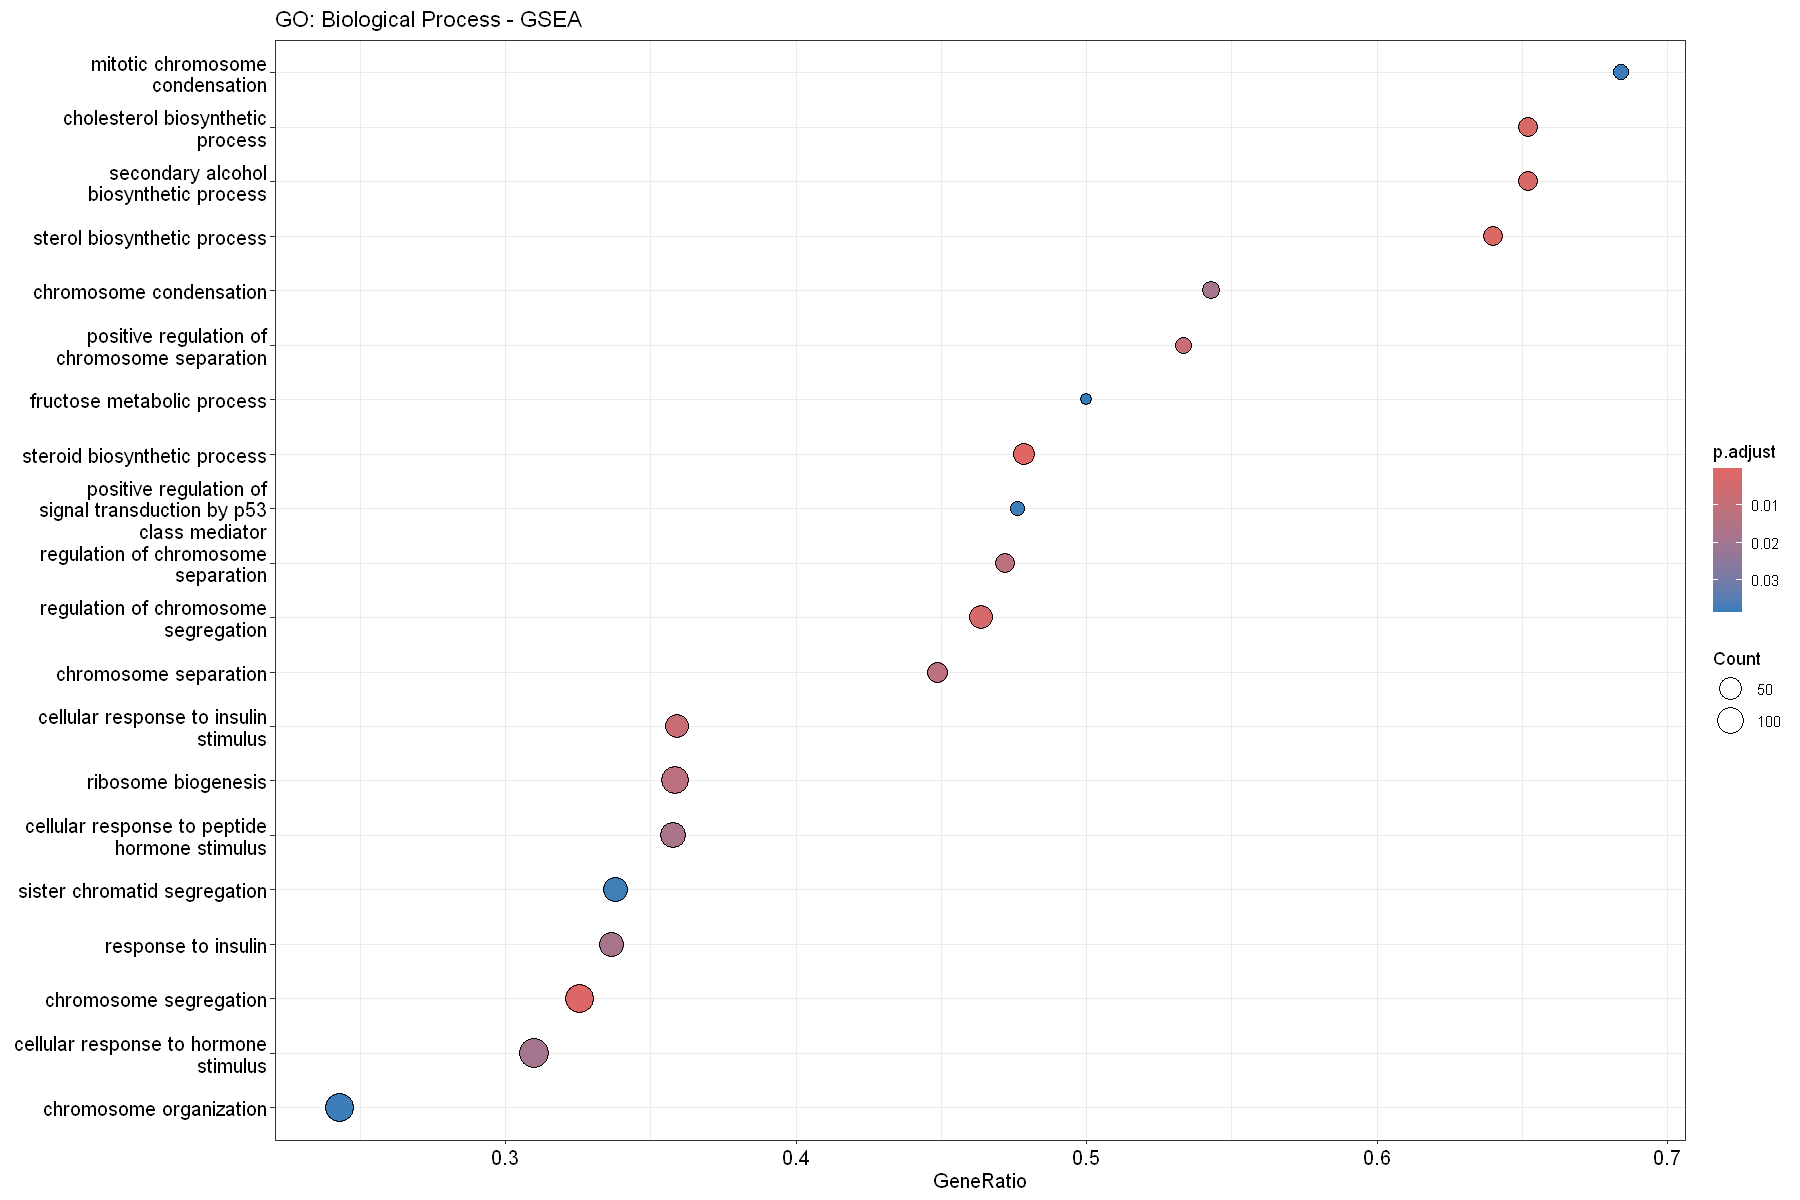

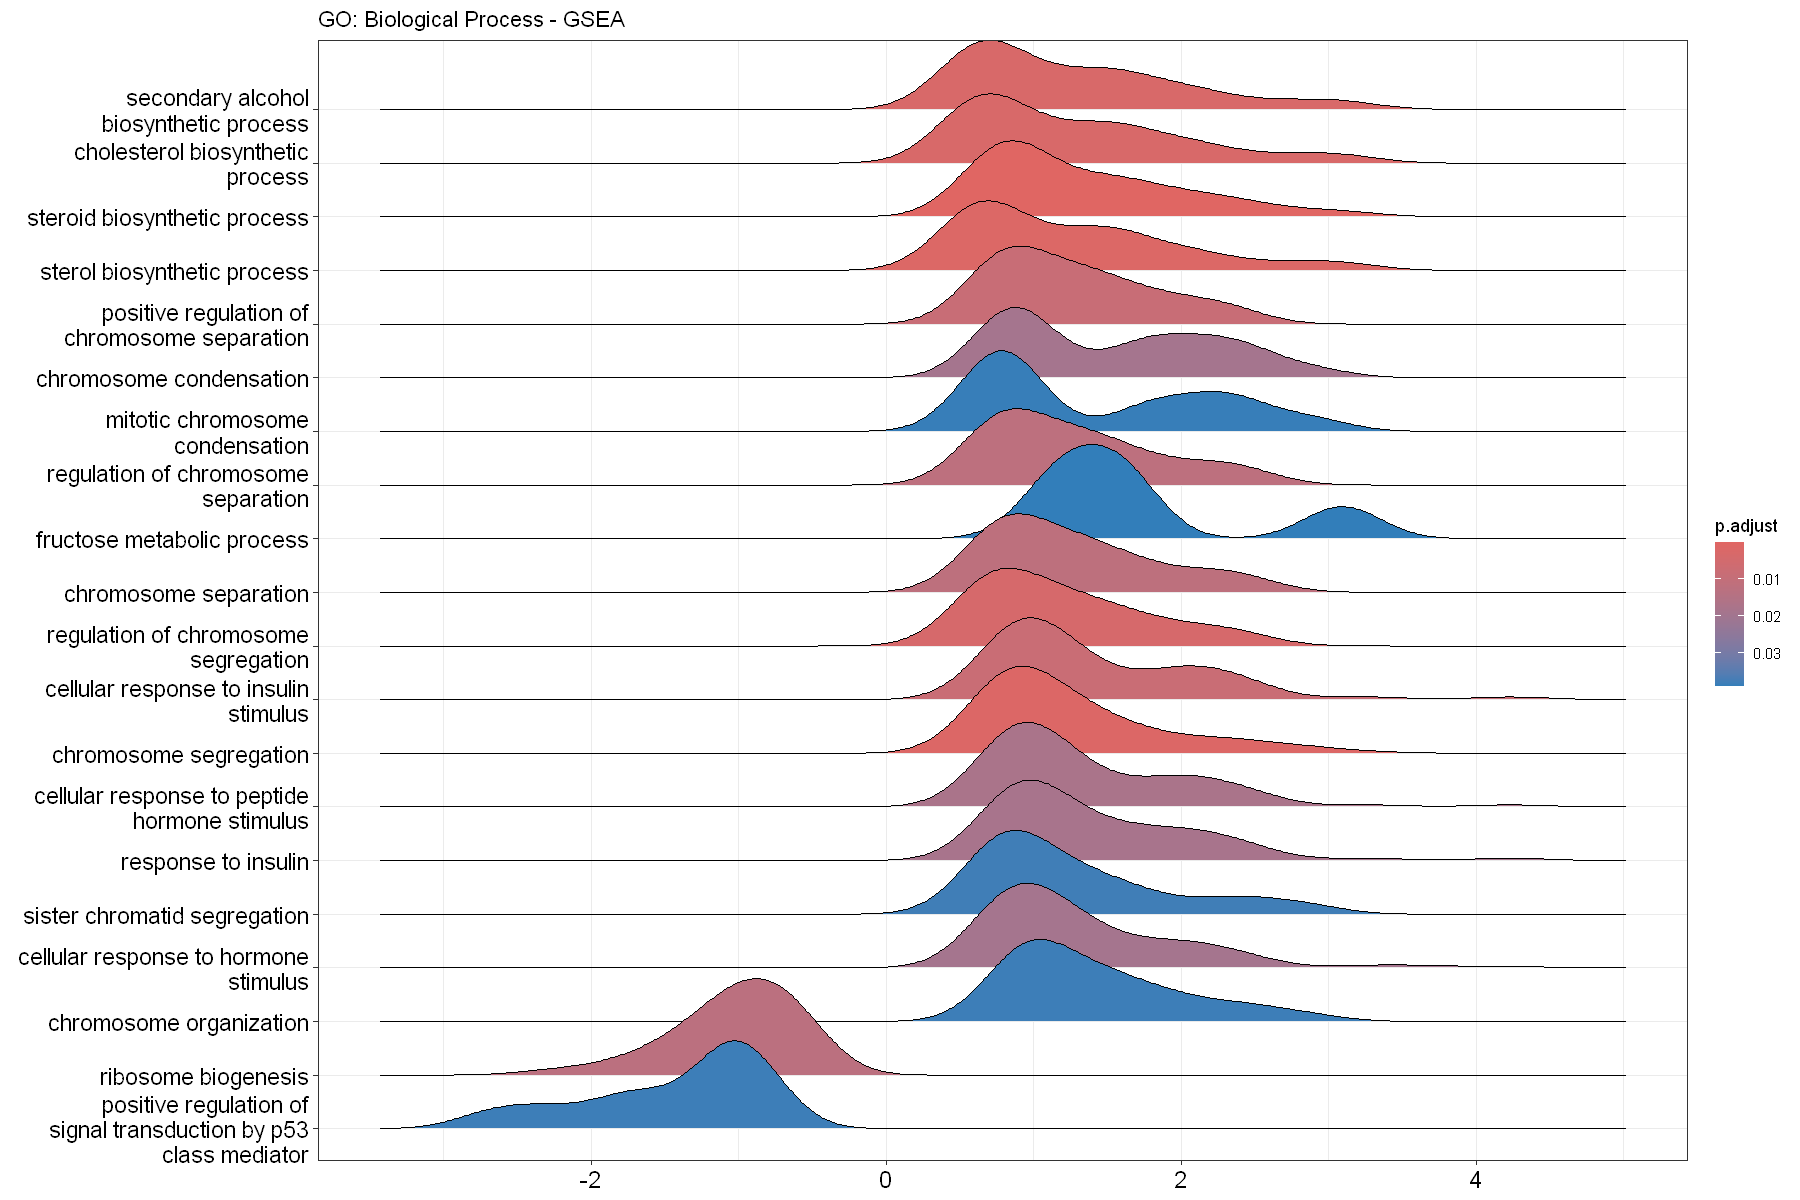

In [ ]:
# Cleaning and sorting the list (decreasing)
res_phe_df <- res_phe_df[!is.na(res_phe_df$stat) & !is.na(res_phe_df$gene_symbol), ]
stat_list <- res_phe_df$stat

names(stat_list) <- res_phe_df$gene_symbol
stat_list <- sort(stat_list, decreasing = TRUE)

# Eliminating duplicates: keeping the strongest signal
df <- data.frame(
  gene = names(stat_list),
  stat = stat_list,
  stringsAsFactors = FALSE
)
df_clean <- df %>%
  group_by(gene) %>%
  slice_max(order_by = abs(stat), n = 1, with_ties = FALSE) %>%
  ungroup()
stat_list <- df_clean$stat
names(stat_list) <- df_clean$gene
stat_list <- sort(stat_list, decreasing = TRUE)


#GSEA
gsea_res <- gseGO(
  geneList = stat_list,
  OrgDb = org.Hs.eg.db,
  ont = "BP",
  keyType = "SYMBOL",
  verbose = FALSE
)

#Plots
gseaplot2(gsea_res, geneSetID = 1)
dotplot(gsea_res, showCategory = 20, title = "GO: Biological Process - GSEA")
p <- ridgeplot(gsea_res, showCategory = 20)         #library(ggridges)
p + ggtitle("GO: Biological Process - GSEA")

### **Results**

As previously stated, it is important to remember that ORA has less statistical significance in this specific set-up compared to GSEA, and therefore the latter must be used as the reference among the two for this FE analysis.  
From ORA, 7 significant GO terms were obtained, related to cellular response to nitrogen compounds and peptide hormones, tissue morphogenesis, cell migration, and renal processes. It is immediately evident that several processes are interestingly shared with the isolated genes of the previous enrichment, CFAP44 and ASDURF.   
The GSEA profile shows predominantly upregulation of BPs upon Phe treatment, rather than downregulation. The main GO terms are related to chromosomal segregation, sterol and alcohol biosynthesis, and cellular response to hormones, among others. The main GO terms associated with downregulation are "ribosome biogenesis" and "positive regulation of signal transduction by p53 class mediator".  
<br>
Overall, the GSEA results apparently differ substantially from ORA, with the exception of cellular response to hormones. However, many of the terms resulting from the GSEA, such as those involved in cell cycle regulation, are potentially connected to differentiation, cell migration, and nitrogen compound response. Especially the chromosome-related BPs suggest strong proliferative activity, pointing towards a general reduction in differentiation, and increased motility and tissue specification. Interestingly, this is extremely consistent with the findings on the DE genes for adjusted p-value.  
Comparing all three FE analyses, clear and consistent parallels are found. Indeed, it is reasonable to conclude that the phenylalanine treatment has a relevant influence primarily on cell cycle regulation and differentiation, along with related processes such as tissue specification and cell motility. Moreover, a common involvement in hormone signalling and synthesis, and in renal metabolism was shown.

# *Conclusions*

### Final considerations and open issues

To summarize, the effect of L-phenylalanine on activated Th2 cells was investigated using RNA-Seq analysis. Each of the 5 donors provided 2 different samples: one treated with L-phenylalanine and one used as a control sample.  
Illumina RNA-Seq raw reads were retrieved from the SRA database, quality control was performed, and low-quality reads were trimmed, along with any remaining adapters. Pseudo-mapping to the reference transcriptome was then performed using Kallisto.  
Counts resulting from the pseudo-mapping were imported into R, and differential expression analysis was performed using DESeq2 under a paired experimental design: design = ~ Donor + PheTreatment. Nine genes passed the threshold for the adjusted p-value, thus resulting as differentially expressed. A search in the literature and the STRING database revealed functional involvement of this group in differentiation, cell cycle regulation, cell migration, and renal processes. Functional enrichment analysis of the 549 genes that were differentially expressed according to raw p-value confirmed enrichment in these biological processes, also suggesting a further effect on hormone biosynthesis and signaling pathways.
<br>

It is still important to consider some remaining issues, and proposed improvements:  
- Kallisto mapping: Kallisto is fast but is not the gold standard for RNA-Seq analysis. The results are perfectly reliable for this kind of analysis, but it would be worthwhile to repeat the analysis using a more exhaustive aligner such as HISAT2 or STAR.
- Batch effect: It is possible that batch effect is causing the observed inter-donor variability. If so, it should be incorporated into the statistical model. However, no information is available to assess this.
- Low baseline expression bias: A log2FC shrinkage can be considered to account for low baseline expression biases.

Overall, Phe treatment does not appear to have an extremely strong effect, but rather to have a moderate influence on certain biological processes, most notably differentiation, motility, hormone signalling and renal metabolism. These considerations should be expanded with further literature research and experiments.